# B5 행사 데이터 EDA
**데이터**: `data/processed/B5_MNM_DATA.parquet` 59,247행 x 15열 (행사기준 null 3건 제거 후)

## 분석 결과 요약
| 항목 | 결과 |
|------|------|
| 프로모션 노드 기준 | 프로모션_타입 (18종, 싱글턴 0%) |
| 포함 카테고리 기준 | `경희대학교_B팀_타겟카테고리_선정안.xlsx` 포함 62개 중분류 |
| 콤보할인 처리 | 할인매가 null -> 행사매가로 fill + is_combo 플래그 |

In [1]:
import polars as pl
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.ticker as ticker
import os
import re  
import seaborn as sns

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

BASE = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
B5_PATH  = os.path.join(BASE, 'data', 'processed', 'B5_MNM_DATA.parquet')
B4_PATH  = os.path.join(BASE, 'data', 'processed', 'B4_ITEM_DV_INFO.parquet')
B2_PATH         = os.path.join(BASE, 'data', 'processed', 'POS 전처리 최종',
                               'pos_data_food_final_상품단위변환전.parquet')
B2_PRODUCT_PATH = os.path.join(BASE, 'data', 'processed', 'POS 전처리 최종',
                               '최종_상품단위_데이터셋.csv')

print('B5 존재:', os.path.exists(B5_PATH))
print('B4 존재:', os.path.exists(B4_PATH))
print('B2 존재:', os.path.exists(B2_PATH))
print('B2_PRODUCT 존재:', os.path.exists(B2_PRODUCT_PATH))

B5 존재: True
B4 존재: True
B2 존재: True
B2_PRODUCT 존재: True


## 1. 기본 구조 & 결측치 감사
- Shape: (59,250, 15)
- 주요 결측: 행사형태 66.4% null (번들증정 외 타입은 행사유형으로 대체), 행사기준 0.005%

In [2]:
df = pl.read_parquet(B5_PATH)
print(f'Shape: {df.shape}')
print()
print('컬럼 및 dtype:')
for col, dtype in zip(df.columns, df.dtypes):
    print(f'  {col:<18} {str(dtype)}')

Shape: (59250, 15)

컬럼 및 dtype:
  행사기준               String
  행사정보코드             String
  행사코드               Int64
  행사명                String
  행사개시일              Datetime(time_unit='us', time_zone=None)
  행사종료일              Datetime(time_unit='us', time_zone=None)
  대분류                String
  상품코드               Int64
  상품명                String
  행사원가               Float64
  행사매가               Int64
  할인매가               Float64
  행사형태               String
  행사유형               String
  정산방식               String


In [3]:
# 결측치 & cardinality 요약
rows = []
for col in df.columns:
    s = df[col]
    null_n = s.null_count()
    null_r = round(null_n / len(df) * 100, 1)
    n_unique = s.n_unique()
    rows.append({'컬럼': col, '결측수': null_n, '결측율(%)': null_r, '고유값수': n_unique})

summary = pd.DataFrame(rows)
display(summary)

,컬럼,결측수,결측율(%),고유값수
0,행사기준,3,0.0,191
1,행사정보코드,0,0.0,14065
2,행사코드,0,0.0,14067
3,행사명,0,0.0,8393
4,행사개시일,0,0.0,280
5,행사종료일,0,0.0,205
6,대분류,0,0.0,33
7,상품코드,0,0.0,7079
8,상품명,0,0.0,7032
9,행사원가,0,0.0,3172


In [4]:
# 범주형 컬럼 value_counts 미리보기
cat_cols = [col for col, dt in zip(df.columns, df.dtypes) if dt == pl.String]
print(f'String 컬럼 ({len(cat_cols)}개): {cat_cols}\n')

for col in cat_cols:
    vc = df[col].value_counts().sort('count', descending=True).head(5)
    print(f'[{col}] top-5')
    print(vc)
    print()

String 컬럼 (8개): ['행사기준', '행사정보코드', '행사명', '대분류', '상품명', '행사형태', '행사유형', '정산방식']

[행사기준] top-5
shape: (5, 2)
┌─────────────────────────┬───────┐
│ 행사기준                ┆ count │
│ ---                     ┆ ---   │
│ str                     ┆ u32   │
╞═════════════════════════╪═══════╡
│ ★25년 7월 정기 M&M행사  ┆ 4250  │
│ ★25년 10월 정기 M&M행사 ┆ 3937  │
│ ★25년 8월 정기 M&M행사  ┆ 3595  │
│ ★25년 9월 정기 M&M행사  ┆ 3367  │
│ ★25년 6월 정기 M&M행사  ┆ 3218  │
└─────────────────────────┴───────┘

[행사정보코드] top-5
shape: (5, 2)
┌──────────────┬───────┐
│ 행사정보코드 ┆ count │
│ ---          ┆ ---   │
│ str          ┆ u32   │
╞══════════════╪═══════╡
│ 145381       ┆ 204   │
│ 145407       ┆ 204   │
│ 146298       ┆ 202   │
│ 147434       ┆ 202   │
│ 146166       ┆ 201   │
└──────────────┴───────┘

[행사명] top-5
shape: (5, 2)
┌─────────────────────────────────┬───────┐
│ 행사명                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞══════════════════════════════

=== 행사형태 value_counts (null 포함) ===
shape: (12, 2)
┌──────────┬───────┐
│ 행사형태 ┆ count │
│ ---      ┆ ---   │
│ str      ┆ u32   │
╞══════════╪═══════╡
│ null     ┆ 39351 │
│ 2+1      ┆ 12789 │
│ 1+1      ┆ 6560  │
│ 10+1     ┆ 214   │
│ 3+1      ┆ 190   │
│ …        ┆ …     │
│ 2+2      ┆ 15    │
│ 8+1      ┆ 12    │
│ 6+1      ┆ 10    │
│ 9+1      ┆ 6     │
│ 7+1      ┆ 4     │
└──────────┴───────┘

null 수: 39351

=== 행사유형 value_counts ===
shape: (12, 2)
┌─────────────────────┬───────┐
│ 행사유형            ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ 0101 : 번들증정     ┆ 19818 │
│ 0203 : 번들할인     ┆ 11248 │
│ 0301 : 구독행사     ┆ 7269  │
│ 0103 : 번들할인     ┆ 6355  │
│ 0106 : 단품할인     ┆ 6245  │
│ …                   ┆ …     │
│ 0102 : 콤보증정     ┆ 720   │
│ 0205 : 장바구니할인 ┆ 455   │
│ 0201 : 번들증정     ┆ 81    │
│ 0206 : 단품할인     ┆ 25    │
│ 0105 : 장바구니할인 ┆ 2     │
└─────────────────────┴───────┘

=== 행사유형별 행사형태 null 비율 ===
shape: (12, 4)


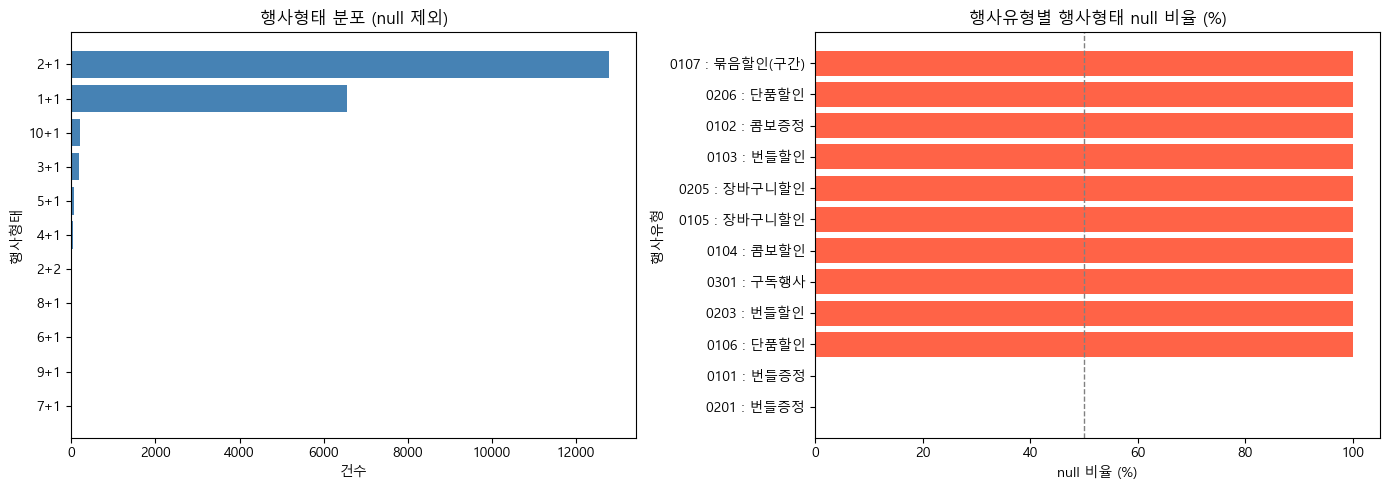

In [5]:
# 행사형태 전체 분포 (null 포함)
print("=== 행사형태 value_counts (null 포함) ===")
vc_형태 = df['행사형태'].value_counts(sort=True)
print(vc_형태)
print(f"\nnull 수: {df['행사형태'].null_count()}")

# 행사유형 전체 분포
print("\n=== 행사유형 value_counts ===")
vc_유형 = df['행사유형'].value_counts(sort=True)
print(vc_유형)

# 행사형태 null 여부 flag 생성 후 행사유형별 null 비율 계산
df_flag = df.with_columns(
    pl.col('행사형태').is_null().alias('형태_null')
)

crosstab = (
    df_flag
    .group_by('행사유형')
    .agg([
        pl.len().alias('전체'),
        pl.col('형태_null').sum().alias('형태_null_수'),
    ])
    .with_columns(
        (pl.col('형태_null_수') / pl.col('전체') * 100).round(1).alias('null_비율(%)')
    )
    .sort('null_비율(%)', descending=True)
)

print("\n=== 행사유형별 행사형태 null 비율 ===")
print(crosstab)

# 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 행사형태 분포 (null 제외)
형태_non_null = df['행사형태'].drop_nulls().value_counts(sort=True).to_pandas()
axes[0].barh(형태_non_null['행사형태'], 형태_non_null['count'], color='steelblue')
axes[0].set_title('행사형태 분포 (null 제외)')
axes[0].set_xlabel('건수')
axes[0].set_ylabel('행사형태')
axes[0].invert_yaxis()

# 행사유형별 형태_null 비율
ct_pd = crosstab.to_pandas()
colors = ['tomato' if r > 50 else 'steelblue' for r in ct_pd['null_비율(%)']]
axes[1].barh(ct_pd['행사유형'], ct_pd['null_비율(%)'], color=colors)
axes[1].set_title('행사유형별 행사형태 null 비율 (%)')
axes[1].set_xlabel('null 비율 (%)')
axes[1].set_ylabel('행사유형')
axes[1].axvline(x=50, color='gray', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()


## 2. 행사유형 -> 프로모션_타입 통합
**문제**: 행사형태(null 66%)와 행사유형(코드:레이블 형태)이 분리되어 있음

**처리**: 번들증정 타입은 행사형태 값 사용, 나머지는 행사유형에서 레이블만 추출 -> 프로모션_타입 컬럼 생성

In [6]:
# 번들증정 행사유형의 정확한 값 확인 (코드:레이블 형태일 수 있음)
bundle_vals = (
    df.filter(pl.col('행사형태').is_not_null())
    ['행사유형']
    .unique()
    .to_list()
)
print("번들증정에 해당하는 행사유형 값:", bundle_vals)

# 프로모션_타입 생성
df = df.with_columns(
    pl.when(pl.col('행사유형').is_in(bundle_vals))
    .then(pl.col('행사형태'))
    .otherwise(pl.col('행사유형'))
    .alias('프로모션_타입')
)

# 원본 컬럼 제거
df = df.drop(['행사유형', '행사형태'])

# 검증
print("\n=== 프로모션_타입 value_counts ===")
print(df['프로모션_타입'].value_counts(sort=True))
print(f"\nnull 수: {df['프로모션_타입'].null_count()}")
print(f"\n최종 shape: {df.shape}")
print("\n컬럼 목록:")
print(df.columns)

번들증정에 해당하는 행사유형 값: ['0101 : 번들증정', '0201 : 번들증정']

=== 프로모션_타입 value_counts ===
shape: (21, 2)
┌─────────────────────┬───────┐
│ 프로모션_타입       ┆ count │
│ ---                 ┆ ---   │
│ str                 ┆ u32   │
╞═════════════════════╪═══════╡
│ 2+1                 ┆ 12789 │
│ 0203 : 번들할인     ┆ 11248 │
│ 0301 : 구독행사     ┆ 7269  │
│ 1+1                 ┆ 6560  │
│ 0103 : 번들할인     ┆ 6355  │
│ …                   ┆ …     │
│ 8+1                 ┆ 12    │
│ 6+1                 ┆ 10    │
│ 9+1                 ┆ 6     │
│ 7+1                 ┆ 4     │
│ 0105 : 장바구니할인 ┆ 2     │
└─────────────────────┴───────┘

null 수: 0

최종 shape: (59250, 14)

컬럼 목록:
['행사기준', '행사정보코드', '행사코드', '행사명', '행사개시일', '행사종료일', '대분류', '상품코드', '상품명', '행사원가', '행사매가', '할인매가', '정산방식', '프로모션_타입']


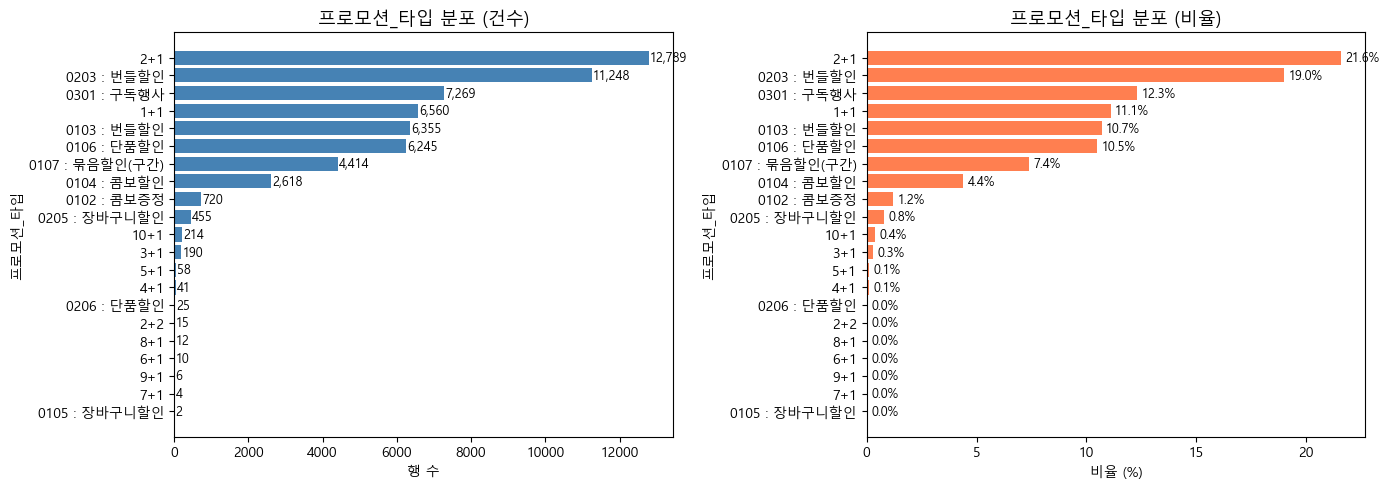

        프로모션_타입  count  비율(%)
            2+1  12789   21.6
    0203 : 번들할인  11248   19.0
    0301 : 구독행사   7269   12.3
            1+1   6560   11.1
    0103 : 번들할인   6355   10.7
    0106 : 단품할인   6245   10.5
0107 : 묶음할인(구간)   4414    7.4
    0104 : 콤보할인   2618    4.4
    0102 : 콤보증정    720    1.2
  0205 : 장바구니할인    455    0.8
           10+1    214    0.4
            3+1    190    0.3
            5+1     58    0.1
            4+1     41    0.1
    0206 : 단품할인     25    0.0
            2+2     15    0.0
            8+1     12    0.0
            6+1     10    0.0
            9+1      6    0.0
            7+1      4    0.0
  0105 : 장바구니할인      2    0.0


In [7]:
vc = df['프로모션_타입'].value_counts(sort=True).to_pandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 건수 기준
axes[0].barh(vc['프로모션_타입'], vc['count'], color='steelblue')
axes[0].set_title('프로모션_타입 분포 (건수)', fontsize=13)
axes[0].set_xlabel('행 수')
axes[0].set_ylabel('프로모션_타입')
axes[0].invert_yaxis()
for i, v in enumerate(vc['count']):
    axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# 우: 비율 기준
total = vc['count'].sum()
vc['비율(%)'] = (vc['count'] / total * 100).round(1)
axes[1].barh(vc['프로모션_타입'], vc['비율(%)'], color='coral')
axes[1].set_title('프로모션_타입 분포 (비율)', fontsize=13)
axes[1].set_xlabel('비율 (%)')
axes[1].set_ylabel('프로모션_타입')
axes[1].invert_yaxis()
for i, v in enumerate(vc['비율(%)']):
    axes[1].text(v + 0.2, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(vc[['프로모션_타입', 'count', '비율(%)']].to_string(index=False))


In [8]:
df = df.with_columns(
    pl.col("프로모션_타입")
    .str.split(" : ")          # " : " 기준으로 나누기 (리스트 반환)
    .list.get(-1)             # 리스트의 마지막 요소(즉, : 뒤의 값) 가져오기
    .str.replace_all(r"\s+", "") # 모든 공백(띄어쓰기, 탭 등) 제거
)

### 프로모션_타입 레이블 정제
코드 : 레이블 형태를 ' : ' 기준 split 후 마지막 요소만 추출, 공백 전체 제거

=== 프로모션_타입별 할인매가 null 비율 ===
shape: (18, 4)
┌───────────────┬───────┬─────────┬──────────────┐
│ 프로모션_타입 ┆ 전체  ┆ null_수 ┆ null_비율(%) │
│ ---           ┆ ---   ┆ ---     ┆ ---          │
│ str           ┆ u32   ┆ u32     ┆ f64          │
╞═══════════════╪═══════╪═════════╪══════════════╡
│ 콤보할인      ┆ 2618  ┆ 2083    ┆ 79.6         │
│ 장바구니할인  ┆ 457   ┆ 1       ┆ 0.2          │
│ 단품할인      ┆ 6270  ┆ 0       ┆ 0.0          │
│ 콤보증정      ┆ 720   ┆ 0       ┆ 0.0          │
│ 구독행사      ┆ 7269  ┆ 0       ┆ 0.0          │
│ …             ┆ …     ┆ …       ┆ …            │
│ 9+1           ┆ 6     ┆ 0       ┆ 0.0          │
│ 5+1           ┆ 58    ┆ 0       ┆ 0.0          │
│ 6+1           ┆ 10    ┆ 0       ┆ 0.0          │
│ 번들할인      ┆ 17603 ┆ 0       ┆ 0.0          │
│ 3+1           ┆ 190   ┆ 0       ┆ 0.0          │
└───────────────┴───────┴─────────┴──────────────┘

=== non-null 행 할인매가 vs 행사매가 관계 (총 57,166건) ===
  할인매가 == 행사매가 : 32,444건 (56.8%)
  할인매가 <  행사매가 : 24,722건 (43.2%)
  할인매가 >  행

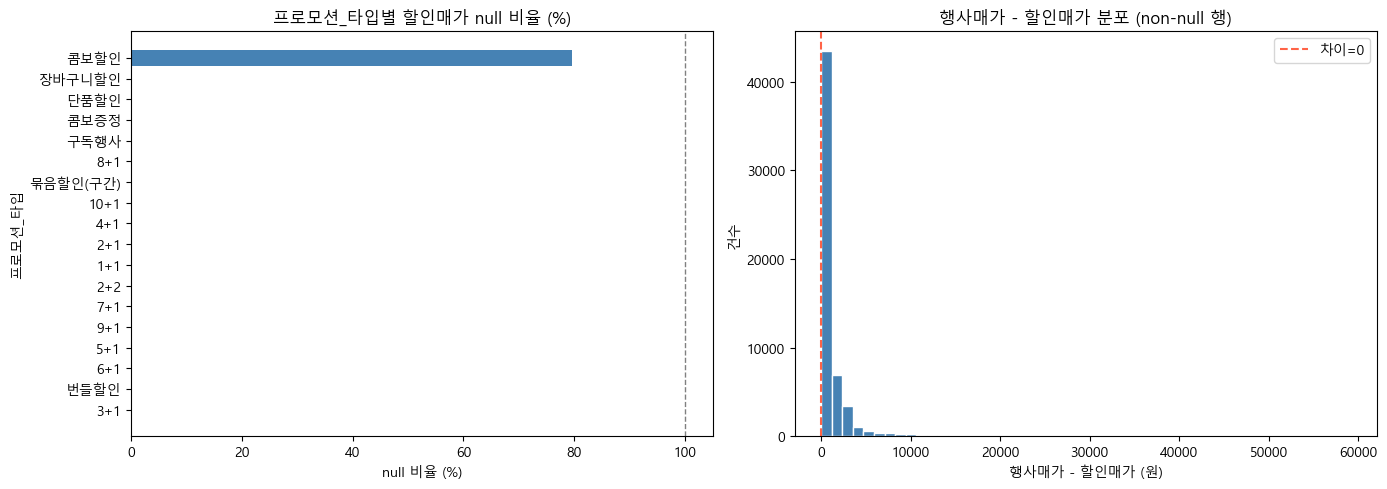

In [9]:
# 1. 프로모션_타입별 할인매가 null 비율
crosstab = (
    df.with_columns(pl.col('할인매가').is_null().alias('할인매가_null'))
    .group_by('프로모션_타입')
    .agg([
        pl.len().alias('전체'),
        pl.col('할인매가_null').sum().alias('null_수'),
    ])
    .with_columns(
        (pl.col('null_수') / pl.col('전체') * 100).round(1).alias('null_비율(%)')
    )
    .sort('null_비율(%)', descending=True)
)
print("=== 프로모션_타입별 할인매가 null 비율 ===")
print(crosstab)

# 2. non-null 행에서 할인매가와 행사매가 비교
df_non_null = df.filter(pl.col('할인매가').is_not_null())

equal_count = df_non_null.filter(pl.col('할인매가') == pl.col('행사매가')).shape[0]
less_count  = df_non_null.filter(pl.col('할인매가') <  pl.col('행사매가')).shape[0]
more_count  = df_non_null.filter(pl.col('할인매가') >  pl.col('행사매가')).shape[0]
total_non_null = df_non_null.shape[0]

print(f"\n=== non-null 행 할인매가 vs 행사매가 관계 (총 {total_non_null:,}건) ===")
print(f"  할인매가 == 행사매가 : {equal_count:,}건 ({equal_count/total_non_null*100:.1f}%)")
print(f"  할인매가 <  행사매가 : {less_count:,}건 ({less_count/total_non_null*100:.1f}%)")
print(f"  할인매가 >  행사매가 : {more_count:,}건 ({more_count/total_non_null*100:.1f}%)")

# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: 프로모션_타입별 null 비율
ct_pd = crosstab.to_pandas()
colors = ['tomato' if r == 100 else 'steelblue' for r in ct_pd['null_비율(%)']]
axes[0].barh(ct_pd['프로모션_타입'], ct_pd['null_비율(%)'], color=colors)
axes[0].set_title('프로모션_타입별 할인매가 null 비율 (%)')
axes[0].set_xlabel('null 비율 (%)')
axes[0].set_ylabel('프로모션_타입')
axes[0].axvline(x=100, color='gray', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

# 우: non-null 행 할인매가 분포 (행사매가 대비)
diff = (df_non_null['행사매가'].cast(pl.Float64) - df_non_null['할인매가']).to_pandas()
axes[1].hist(diff, bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('행사매가 - 할인매가 분포 (non-null 행)')
axes[1].set_xlabel('행사매가 - 할인매가 (원)')
axes[1].set_ylabel('건수')
axes[1].axvline(x=0, color='tomato', linestyle='--', linewidth=1.5, label='차이=0')
axes[1].legend()

plt.tight_layout()
plt.show()


In [10]:
combo_null = (
    df
    .filter((pl.col('프로모션_타입') == '콤보할인') & pl.col('할인매가').is_null())
)

print(f"콤보할인 + 할인매가 null: {combo_null.shape[0]}건\n")
print("=== 행사명 분포 ===")
print(combo_null['행사명'].value_counts(sort=True))


콤보할인 + 할인매가 null: 2083건

=== 행사명 분포 ===
shape: (122, 2)
┌─────────────────────────────────┬───────┐
│ 행사명                          ┆ count │
│ ---                             ┆ ---   │
│ str                             ┆ u32   │
╞═════════════════════════════════╪═══════╡
│ 삼각김밥+칠성사이다제로250ml콤  ┆ 82    │
│ 보할인행사(12월)                ┆       │
│ 삼각김밥+칠성사이다제로250ml콤  ┆ 81    │
│ 보할인행사(10월)                ┆       │
│ 삼각김밥+칠성사이다제로250ml콤  ┆ 80    │
│ 보할인행사(8월)                 ┆       │
│ 샌드위치+칠성사이다제로250ml콤  ┆ 51    │
│ 보할인행사(12월)                ┆       │
│ 삼각김밥+칠성사이다제로250ml콤  ┆ 44    │
│ 보할인행사(9월)                 ┆       │
│ …                               ┆ …     │
│ 3월 세븐카페 텀블러 행사        ┆ 1     │
│ 2월 맥주 번들 콤보 할인 행사    ┆ 1     │
│ 2월 세븐카페 텀블러 행사        ┆ 1     │
│ 1월 세븐카페 텀블러 행사        ┆ 1     │
│ 1월 맥주 콤보 할인 행사         ┆ 1     │
└─────────────────────────────────┴───────┘


## 3. 가격 컬럼 결측치 처리
**할인매가 null 분석**
- 콤보할인: null 비율 79.5% -> 행사매가 기준이라 할인매가 없음
- 처리: is_combo 플래그 추가 후 할인매가 null -> 행사매가로 fill
- 처리 후 할인매가 null 잔여: 0건

In [11]:
# 콤보할인의 경우 행사매가를 할인매가로 처리, combo 여부 flag로 표시
# is_combo 플래그
df = df.with_columns(
    (pl.col('프로모션_타입') == '콤보할인').alias('is_combo')
)

# 콤보할인 + 할인매가 null → POS 평균단가로 우선 fill
pos_price = (
    pl.scan_parquet(B2_PATH)
    .select(['상품코드', '매출금액', '매출수량'])
    .filter(pl.col('매출수량') > 0)
    .group_by('상품코드')
    .agg((pl.col('매출금액').sum() / pl.col('매출수량').sum()).alias('pos_단가'))
    .collect()
    .with_columns(pl.col('상품코드').cast(pl.String).str.zfill(6))
)

df = (
    df
    .with_columns(pl.col('상품코드').cast(pl.String).str.zfill(6).alias('상품코드_str'))
    .join(pos_price, left_on='상품코드_str', right_on='상품코드', how='left')
    .with_columns(
        pl.when(
            (pl.col('프로모션_타입') == '콤보할인') & pl.col('할인매가').is_null()
        )
        .then(pl.col('pos_단가').cast(pl.Float64))
        .otherwise(pl.col('할인매가'))
        .alias('할인매가')
    )
    .drop('pos_단가')
)

combo_null_after = df.filter(
    (pl.col('프로모션_타입') == '콤보할인') & pl.col('할인매가').is_null()
).shape[0]
print(f"콤보할인 + 할인매가 null (POS fill 후): {combo_null_after}건")

# 나머지 null → 행사매가로 fill
df = df.with_columns(
    pl.col('할인매가')
    .fill_null(pl.col('행사매가').cast(pl.Float64))
)

# 검증
print(f"할인매가 null 잔여: {df['할인매가'].null_count()}")
print(f"is_combo True: {df['is_combo'].sum()}건")
print(f"\n=== is_combo별 할인매가 vs 행사매가 일치 비율 ===")
check = (
    df.with_columns(
        (pl.col('할인매가') == pl.col('행사매가').cast(pl.Float64)).alias('일치')
    )
    .group_by('is_combo')
    .agg([
        pl.len().alias('전체'),
        pl.col('일치').sum().alias('일치_수'),
    ])
    .with_columns(
        (pl.col('일치_수') / pl.col('전체') * 100).round(1).alias('일치율(%)')
    )
)
print(check)


콤보할인 + 할인매가 null (POS fill 후): 72건
할인매가 null 잔여: 0
is_combo True: 2618건

=== is_combo별 할인매가 vs 행사매가 일치 비율 ===
shape: (2, 4)
┌──────────┬───────┬─────────┬───────────┐
│ is_combo ┆ 전체  ┆ 일치_수 ┆ 일치율(%) │
│ ---      ┆ ---   ┆ ---     ┆ ---       │
│ bool     ┆ u32   ┆ u32     ┆ f64       │
╞══════════╪═══════╪═════════╪═══════════╡
│ false    ┆ 56632 ┆ 32445   ┆ 57.3      │
│ true     ┆ 2618  ┆ 92      ┆ 3.5       │
└──────────┴───────┴─────────┴───────────┘


In [12]:
# 행사기준 null 드롭
before = df.shape[0]
df = df.filter(pl.col('행사기준').is_not_null())
print(f"행사기준 null 드롭: {before} → {df.shape[0]}행 ({before - df.shape[0]}건 제거)")

# 9999 sentinel 비율
sentinel_n = df.filter(pl.col('행사종료일').dt.year() == 9999).shape[0]
total = df.shape[0]
print(f"\n행사종료일 9999 sentinel: {sentinel_n:,}건 ({sentinel_n/total*100:.1f}%)")
print(f"유효 종료일: {total - sentinel_n:,}건 ({(total-sentinel_n)/total*100:.1f}%)")


행사기준 null 드롭: 59250 → 59247행 (3건 제거)

행사종료일 9999 sentinel: 21건 (0.0%)
유효 종료일: 59,226건 (100.0%)


In [13]:

results = []

# 1. Datetime 컬럼: 정상 범위(2010~2026) 밖 연도 확인
dt_cols = [col for col, dt in zip(df.columns, df.dtypes) if dt == pl.Datetime('us')]
print("=== Datetime 컬럼 이상 연도 ===")
for col in dt_cols:
    abnormal = df.filter(
        (pl.col(col).dt.year() < 2010) | (pl.col(col).dt.year() > 2026)
    )
    years = abnormal[col].dt.year().value_counts(sort=True).to_pandas()
    print(f"\n[{col}] 이상 연도 {abnormal.shape[0]}건")
    if not years.empty:
        print(years)
    results.append({'컬럼': col, '유형': 'Datetime 이상 연도', '건수': abnormal.shape[0]})

# 2. Numeric 컬럼: 0값, 음수, 상한 이상값 확인
num_cols = [col for col, dt in zip(df.columns, df.dtypes)
            if dt in (pl.Int64, pl.Float64)]
print("\n\n=== Numeric 컬럼 이상값 ===")
for col in num_cols:
    s = df[col].drop_nulls()
    zero_n    = (s == 0).sum()
    neg_n     = (s < 0).sum()
    q99       = s.quantile(0.99)
    extreme_n = (s > q99 * 10).sum()  # 99퍼센타일의 10배 초과
    print(f"[{col}]  0값: {zero_n}건  음수: {neg_n}건  극단값(>99p×10): {extreme_n}건  min={s.min()}  max={s.max()}")
    results.append({'컬럼': col, '유형': 'Numeric 이상값', '건수': int(zero_n + neg_n + extreme_n)})

# 3. String 컬럼: 플레이스홀더 패턴 확인
placeholder_patterns = ['-', 'N/A', 'n/a', '없음', '미정', '0', '미분류', 'null', 'NULL', '?', '.']
str_cols = [col for col, dt in zip(df.columns, df.dtypes) if dt == pl.String]
print("\n\n=== String 컬럼 플레이스홀더 패턴 ===")
for col in str_cols:
    found = {}
    for pat in placeholder_patterns:
        n = (df[col] == pat).sum()
        if n > 0:
            found[pat] = n
    if found:
        print(f"[{col}]  {found}")
    else:
        print(f"[{col}]  이상 없음")
    results.append({'컬럼': col, '유형': 'String 플레이스홀더', '건수': sum(found.values())})

# 요약 테이블
print("\n\n=== 이상값 요약 (건수 > 0) ===")
summary = pd.DataFrame(results)
display(summary[summary['건수'] > 0].reset_index(drop=True))


=== Datetime 컬럼 이상 연도 ===

[행사개시일] 이상 연도 0건

[행사종료일] 이상 연도 21건
   행사종료일  count
0   9999     21


=== Numeric 컬럼 이상값 ===
[행사코드]  0값: 0건  음수: 0건  극단값(>99p×10): 0건  min=87111  max=637642
[상품코드]  0값: 0건  음수: 0건  극단값(>99p×10): 0건  min=12679  max=999999
[행사원가]  0값: 2067건  음수: 0건  극단값(>99p×10): 0건  min=0.0  max=816000.0
[행사매가]  0값: 48건  음수: 0건  극단값(>99p×10): 0건  min=0  max=1124000
[할인매가]  0값: 4418건  음수: 0건  극단값(>99p×10): 0건  min=0.0  max=1124000.0


=== String 컬럼 플레이스홀더 패턴 ===
[행사기준]  이상 없음
[행사정보코드]  이상 없음
[행사명]  이상 없음
[대분류]  이상 없음
[상품명]  이상 없음
[정산방식]  이상 없음
[프로모션_타입]  이상 없음
[상품코드_str]  이상 없음


=== 이상값 요약 (건수 > 0) ===


,컬럼,유형,건수
0,행사종료일,Datetime 이상 연도,21
1,행사원가,Numeric 이상값,2067
2,행사매가,Numeric 이상값,48
3,할인매가,Numeric 이상값,4418


In [14]:
# 프로모션_타입별 0값 분포
for price_col in ['행사원가', '행사매가', '할인매가']:
    zero_df = (
        df.filter(pl.col(price_col) == 0)
        .group_by('프로모션_타입')
        .agg(pl.len().alias('0값_건수'))
        .sort('0값_건수', descending=True)
    )
    total_zero = df.filter(pl.col(price_col) == 0).shape[0]
    print(f"=== [{price_col}] 0값 {total_zero}건 - 프로모션_타입 분포 ===")
    print(zero_df)
    print()

# 행사매가 0인 행 샘플 확인 (가장 의심스러운 케이스)
print("=== 행사매가 0인 행 샘플 ===")
sample = df.filter(pl.col('행사매가') == 0).select([
    '행사명', '프로모션_타입', '행사원가', '행사매가', '할인매가', '상품명'
]).head(10)
print(sample)

# 행사원가 0 + 행사매가 > 0 케이스 (원가만 0인 경우)
원가만zero = df.filter((pl.col('행사원가') == 0) & (pl.col('행사매가') > 0)).shape[0]
둘다zero   = df.filter((pl.col('행사원가') == 0) & (pl.col('행사매가') == 0)).shape[0]
print(f"\n행사원가=0 & 행사매가>0 (원가만 미입력): {원가만zero:,}건")
print(f"행사원가=0 & 행사매가=0 (둘 다 0):      {둘다zero:,}건")


=== [행사원가] 0값 2067건 - 프로모션_타입 분포 ===
shape: (5, 2)
┌───────────────┬──────────┐
│ 프로모션_타입 ┆ 0값_건수 │
│ ---           ┆ ---      │
│ str           ┆ u32      │
╞═══════════════╪══════════╡
│ 구독행사      ┆ 1989     │
│ 콤보할인      ┆ 35       │
│ 콤보증정      ┆ 34       │
│ 번들할인      ┆ 8        │
│ 장바구니할인  ┆ 1        │
└───────────────┴──────────┘

=== [행사매가] 0값 48건 - 프로모션_타입 분포 ===
shape: (4, 2)
┌───────────────┬──────────┐
│ 프로모션_타입 ┆ 0값_건수 │
│ ---           ┆ ---      │
│ str           ┆ u32      │
╞═══════════════╪══════════╡
│ 구독행사      ┆ 32       │
│ 콤보할인      ┆ 12       │
│ 콤보증정      ┆ 3        │
│ 장바구니할인  ┆ 1        │
└───────────────┴──────────┘

=== [할인매가] 0값 4418건 - 프로모션_타입 분포 ===
shape: (6, 2)
┌────────────────┬──────────┐
│ 프로모션_타입  ┆ 0값_건수 │
│ ---            ┆ ---      │
│ str            ┆ u32      │
╞════════════════╪══════════╡
│ 묶음할인(구간) ┆ 4322     │
│ 구독행사       ┆ 55       │
│ 단품할인       ┆ 25       │
│ 콤보할인       ┆ 12       │
│ 콤보증정       ┆ 3        │
│ 장바구니할인   ┆ 1        │
└──

## 4. 이상값 & 데이터 품질 검증
- 행사기준 null 3건 드롭
- 행사종료일 9999 sentinel 21건 (0.04%) -> 진행 중 행사로 해석, 유지
- 날짜 범위 2010~2026 내 정상
- 행사원가 0값: 2,067건 (구독행사, 체험행사 위주) -> 해당 타입 특성으로 유지

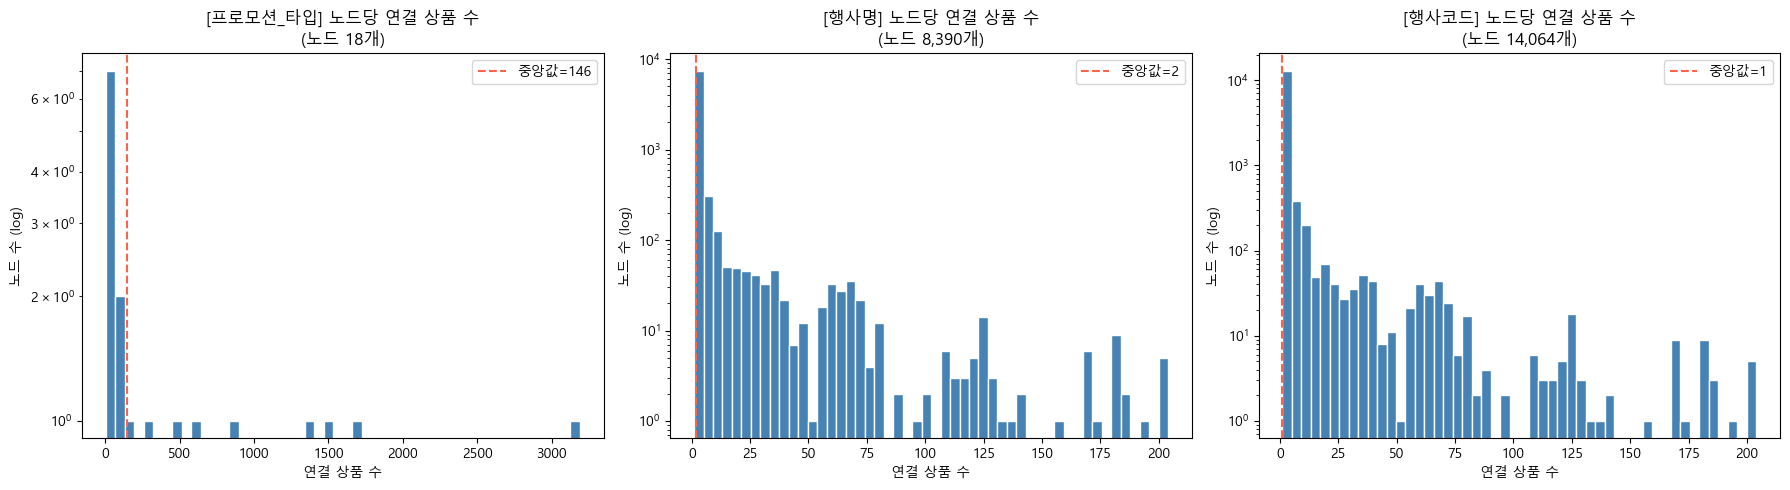

=== granularity별 노드 degree 요약 ===


,granularity,노드수,중앙값_degree,최대_degree,싱글턴(상품1개),싱글턴_비율(%),허브노드(상위1%)
0,프로모션_타입,18,146,3190,0,0.0,1
1,행사명,8390,2,204,4109,49.0,84
2,행사코드,14064,1,204,7509,53.4,154



=== 프로모션_타입별 연결 상품 수 (전체) ===
shape: (18, 2)
┌───────────────┬─────────────┐
│ 프로모션_타입 ┆ 연결_상품수 │
│ ---           ┆ ---         │
│ str           ┆ u32         │
╞═══════════════╪═════════════╡
│ 2+1           ┆ 3190        │
│ 1+1           ┆ 1682        │
│ 번들할인      ┆ 1524        │
│ 단품할인      ┆ 1389        │
│ 구독행사      ┆ 842         │
│ …             ┆ …           │
│ 8+1           ┆ 12          │
│ 6+1           ┆ 10          │
│ 9+1           ┆ 6           │
│ 7+1           ┆ 4           │
│ 2+2           ┆ 3           │
└───────────────┴─────────────┘


In [16]:
# 프로모션 타입 기준으로 결정
# - 행사명/행사코드: 싱글턴 49~53% → 그래프에서 의미 없는 희소 노드가 절반
# - 프로모션_타입: 싱글턴 0%, 18개 노드 모두 충분한 상품과 연결

granularities = {
    '프로모션_타입': '프로모션_타입',
    '행사명':       '행사명',
    '행사코드':     '행사코드',
}

stats_rows = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (label, col) in zip(axes, granularities.items()):
    # 노드당 연결 상품 수 (unique 상품코드 기준)
    degree = (
        df.group_by(col)
        .agg(pl.col('상품코드').n_unique().alias('연결_상품수'))
        .sort('연결_상품수', descending=True)
    )

    deg_pd = degree['연결_상품수'].to_pandas()
    total_nodes = len(deg_pd)
    singleton = (deg_pd == 1).sum()
    hub = (deg_pd >= deg_pd.quantile(0.99)).sum()

    stats_rows.append({
        'granularity': label,
        '노드수': total_nodes,
        '중앙값_degree': int(deg_pd.median()),
        '최대_degree': int(deg_pd.max()),
        '싱글턴(상품1개)': int(singleton),
        '싱글턴_비율(%)': round(singleton / total_nodes * 100, 1),
        '허브노드(상위1%)': int(hub),
    })

    # 히스토그램 (로그 스케일)
    ax.hist(deg_pd, bins=50, color='steelblue', edgecolor='white', log=True)
    ax.set_title(f'[{label}] 노드당 연결 상품 수\n(노드 {total_nodes:,}개)')
    ax.set_xlabel('연결 상품 수')
    ax.set_ylabel('노드 수 (log)')
    ax.axvline(deg_pd.median(), color='tomato', linestyle='--', linewidth=1.5,
               label=f'중앙값={int(deg_pd.median())}')
    ax.legend()

plt.tight_layout()
plt.show()

# 요약 통계
print("=== granularity별 노드 degree 요약 ===")
display(pd.DataFrame(stats_rows))

# 프로모션_타입 기준 상세 (가장 추상적 레벨)
print("\n=== 프로모션_타입별 연결 상품 수 (전체) ===")
print(
    df.group_by('프로모션_타입')
    .agg(pl.col('상품코드').n_unique().alias('연결_상품수'))
    .sort('연결_상품수', descending=True)
)


=== 상품 degree 기초 통계 (B5 등장 상품 7,079개) ===
count    7079.00
mean        1.49
std         0.74
min         1.00
25%         1.00
50%         1.00
75%         2.00
max         5.00
Name: 프로모션_타입_수, dtype: float64


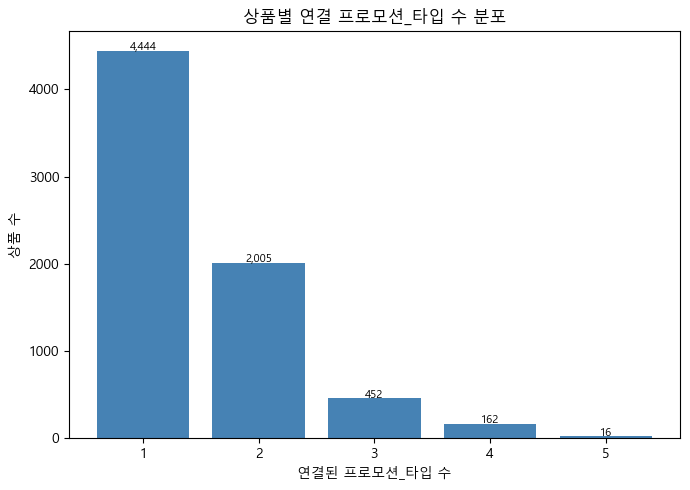

=== 프로모션_타입 3개 이상 연결된 상품 샘플 ===
shape: (10, 3)
┌──────────┬─────────────────────────────────┬──────────────────┐
│ 상품코드 ┆ 상품명                          ┆ 프로모션_타입_수 │
│ ---      ┆ ---                             ┆ ---              │
│ i64      ┆ str                             ┆ u32              │
╞══════════╪═════════════════════════════════╪══════════════════╡
│ 108462   ┆ 화이트)오마이탐폰레귤러8P       ┆ 5                │
│ 105134   ┆ ICE레귤러(에코얼음컵)           ┆ 5                │
│ 124384   ┆ 대림)안심닭가슴살(블랙페퍼)100g ┆ 5                │
│ 126224   ┆ 한도초과)숯불향가득불고기김밥   ┆ 5                │
│ 108463   ┆ 화이트)오마이탐폰슈퍼8P         ┆ 5                │
│ 124732   ┆ 칠성)핫식스더킹메가파워500ml    ┆ 5                │
│ 202326   ┆ 한국)몽베스트생수500ml          ┆ 5                │
│ 108461   ┆ 인테)코코제로망고340ml          ┆ 5                │
│ 105231   ┆ ICE레귤러(아미봉지얼음)         ┆ 5                │
│ 108471   ┆ 인테)코코제로요구르트340ml      ┆ 5                │
└──────────┴─────────────────────────────────┴──────────────────┘


In [18]:
# 상품별 연결된 프로모션_타입 수
product_degree = (
    df.group_by('상품코드')
    .agg(pl.col('프로모션_타입').n_unique().alias('프로모션_타입_수'))
    .sort('프로모션_타입_수', descending=True)
)

deg_pd = product_degree['프로모션_타입_수'].to_pandas()
print(f"=== 상품 degree 기초 통계 (B5 등장 상품 {len(deg_pd):,}개) ===")
print(deg_pd.describe().round(2))

# 프로모션_타입 수별 상품 분포
type_count_dist = (
    product_degree
    .group_by('프로모션_타입_수')
    .agg(pl.len().alias('상품_수'))
    .sort('프로모션_타입_수')
).to_pandas()

# 시각화
fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(type_count_dist['프로모션_타입_수'], type_count_dist['상품_수'], color='steelblue')
ax.set_title('상품별 연결 프로모션_타입 수 분포')
ax.set_xlabel('연결된 프로모션_타입 수')
ax.set_ylabel('상품 수')
for x, y in zip(type_count_dist['프로모션_타입_수'], type_count_dist['상품_수']):
    ax.text(x, y + 10, f"{y:,}", ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# 다수 프로모션에 등장하는 상품 샘플
print("=== 프로모션_타입 3개 이상 연결된 상품 샘플 ===")
multi = (
    df.join(product_degree.filter(pl.col('프로모션_타입_수') >= 3), on='상품코드')
    .select(['상품코드', '상품명', '프로모션_타입_수'])
    .unique()
    .sort('프로모션_타입_수', descending=True)
    .head(10)
)
print(multi)

## 5. HIN 프로모션 노드 설계
**노드 granularity 비교**
| 기준 | 노드 수 | 싱글턴 비율 |
|------|---------|----------|
| 프로모션_타입 | 18개 | 0% (채택) |
| 행사명 | 8,393개 | 약 53% |
| 행사코드 | 14,067개 | 약 49% |

-> 프로모션_타입 기준 채택: 상품당 평균 1.49개 프로모션 타입 연결

## 6. 데이터 커버리지 통일 및 카테고리 필터링 
### 카테고리 필터링 (포함 중분류 62개 -> B4 중분류명 매핑)
- **데이터 소스**: `경희대학교_B팀_타겟카테고리_선정안.xlsx` (포함 62개 / 제외 37개)
- **문제**: B4 중분류명 `'샐러드 '`에 trailing space가 있어 미매칭 발생
- **해결**: `str.strip_chars()` 적용
- **필터링 결과**: 실행 후 업데이트 예정
### 상품코드 매칭: 모두 str로 통일

=== 데이터 타입 통일 후 정합성  확인 ===
- B5 총 상품:             7,079개
- B4 매칭 (상품 마스터):  7,079개 (100.0%)
- B2 매칭 (판매 이력):    5,612개 (79.3%) -> 프로모션 상에는 있지만 POS에 없음: 분석 범위 점포내 POS에 판매 데이터가 존재하지 않음
- B4/B2 모두 미매칭:      0개 (0.0%)

### 상품 커버리지 (B5 <-> B4 <-> B2)
- B4 전체 상품: 159,074개 / B2 판매 상품: 15,553개 / B5 행사 상품: 7,079개
#### === 필터링 결과 - 최종 상품 수:4,386개 ===
- 전체 행: 59,247행, POS 교집합 후: 50,601행(POS 기록에 없는 프로모션의 상품들 제거)
- 카테고리 필터 후: 40,308행 (68.0%) - 분석 카테고리로 한정
- B2 판매 기간: 2025-01-01 ~ 2025-12-31
- B5 zero-padded 후 B4 join으로 카테고리 정보 연결

In [ ]:
df_b4 = pl.read_parquet(B4_PATH)
df_b2 = pl.scan_parquet(B2_PATH).select('상품코드').collect()
df_b2_product = pl.read_csv(B2_PRODUCT_PATH)
df_b2_product = pl.read_csv(B2_PRODUCT_PATH)


print(df_b4.filter(pl.col('상품코드') == 'XXXXXX').shape)
df_b4.filter(pl.col('상품코드') == 'XXXXXX')

In [23]:
# B4: "XXXXXX" 제거
b4_codes = set(
    df_b4.filter(pl.col('상품코드') != 'XXXXXX')['상품코드'].to_list()
)
print(f"B4 상품코드 (XXXXXX 제거 후): {len(b4_codes):,}개")

# B2: String 그대로
b2_codes = set(df_b2['상품코드'].drop_nulls().to_list())
print(f"B2 상품코드: {len(b2_codes):,}개")

# B5: Int64 → 6자리 zero-padded string
b5_codes_str = set(
    df.with_columns(
        pl.col('상품코드').cast(pl.String).str.zfill(6).alias('상품코드_str')
    )['상품코드_str'].to_list()
)
print(f"B5 상품코드 (zero-padded): {len(b5_codes_str):,}개")
print(f"B5 샘플: {list(b5_codes_str)[:5]}")

# 정합성 비교
b5_in_b4    = b5_codes_str & b4_codes
b5_in_b2    = b5_codes_str & b2_codes
b5_in_both  = b5_codes_str & b4_codes & b2_codes
b5_only     = b5_codes_str - b4_codes - b2_codes

print(f"\n=== B5 상품코드 정합성 ===")
print(f"B5 총 상품:             {len(b5_codes_str):,}개")
print(f"B4 매칭 (상품 마스터):  {len(b5_in_b4):,}개 ({len(b5_in_b4)/len(b5_codes_str)*100:.1f}%)")
print(f"B2 매칭 (판매 이력):    {len(b5_in_b2):,}개 ({len(b5_in_b2)/len(b5_codes_str)*100:.1f}%)")
print(f"B4/B2 모두 미매칭:      {len(b5_only):,}개 ({len(b5_only)/len(b5_codes_str)*100:.1f}%)")


B4 상품코드 (XXXXXX 제거 후): 159,074개
B2 상품코드: 10,579개
B5 상품코드 (zero-padded): 7,079개
B5 샘플: ['127621', '100429', '128505', '191256', '106933']

=== B5 상품코드 정합성 ===
B5 총 상품:             7,079개
B4 매칭 (상품 마스터):  7,079개 (100.0%)
B2 매칭 (판매 이력):    5,612개 (79.3%)
B4/B2 모두 미매칭:      0개 (0.0%)


In [24]:
b5_no_b2 = b5_codes_str - b2_codes
sample = df.filter(
    pl.col('상품코드').cast(pl.String).str.zfill(6).is_in(list(b5_no_b2))
).select(['상품코드', '상품명', '프로모션_타입']).unique().head(20)
print(sample)

shape: (20, 3)
┌──────────┬─────────────────────────────────┬───────────────┐
│ 상품코드 ┆ 상품명                          ┆ 프로모션_타입 │
│ ---      ┆ ---                             ┆ ---           │
│ i64      ┆ str                             ┆ str           │
╞══════════╪═════════════════════════════════╪═══════════════╡
│ 107544   ┆ K리그산리오)아크릴볼펜_한교동   ┆ 단품할인      │
│ 401831   ┆ 케이)드림아이여행용세트80ml_H   ┆ 2+1           │
│ 126351   ┆ APP)뚠뚠참치&에그샌드           ┆ 구독행사      │
│ 107814   ┆ K리그산리오)인형                ┆ 단품할인      │
│          ┆ 키링_케로케로피                 ┆               │
│ 107396   ┆ 선린)100W초고속케이블_H         ┆ 1+1           │
│ …        ┆ …                               ┆ …             │
│ 211338   ┆ 하겐)크림치즈모찌파인트473ml    ┆ 2+1           │
│ 104934   ┆ ICE라지(롯데봉지얼음)           ┆ 구독행사      │
│ 125277   ┆ 크리오)대일밴드니플패치12매_H   ┆ 2+1           │
│ 107777   ┆ K리그산리오)스티커세트_한교동   ┆ 단품할인      │
│ 126495   ┆ 디벤)디즈니고양이간식(치킨스틱) ┆ 2+1           │
│          ┆ _H                              ┆             

In [ ]:
print(df_b2.dtypes)                                                                                                                          
print(df_b2['상품코드'].drop_nulls().head(20))                                                                                                

# B2 상품코드 → 6자리 zero-padded string으로 통일                                                                                            
b2_codes_str = set(
    df_b2.with_columns(
        pl.col('상품코드').cast(pl.String).str.zfill(6).alias('상품코드_str')
    )['상품코드_str'].drop_nulls().to_list()
)
print(f"B2 상품코드 (zero-padded): {len(b2_codes_str):,}개")
print(f"B2 샘플: {list(b2_codes_str)[:5]}")

# 동일한 기준으로 재비교
b5_in_b2_v2   = b5_codes_str & b2_codes_str
b5_no_b2_v2   = b5_codes_str - b2_codes_str

print(f"\n=== 형식 통일 후 B5 ↔ B2 정합성 ===")
print(f"B2 매칭: {len(b5_in_b2_v2):,}개 ({len(b5_in_b2_v2)/len(b5_codes_str)*100:.1f}%)")
print(f"B2 미매칭: {len(b5_no_b2_v2):,}개 ({len(b5_no_b2_v2)/len(b5_codes_str)*100:.1f}%)")

# 기존 결과와 비교
print(f"\n기존 미매칭: 1,467개 → 수정 후: {len(b5_no_b2_v2):,}개")
print(f"형식 차이로 인한 오탐: {1467 - len(b5_no_b2_v2):,}개")

[String]
shape: (20,)
Series: '상품코드' [str]
[
	"202316"
	"117969"
	"124518"
	"116368"
	"117048"
	…
	"107180"
	"052908"
	"061530"
	"061530"
	"180074"
]


In [18]:
df_b2_check = pl.scan_parquet(B2_PATH).select('판매시간_dt').collect()                                                                                                                  
print(df_b2_check['판매시간_dt'].min(), '~', df_b2_check['판매시간_dt'].max())

2025-01-01 00:00:01 ~ 2025-12-31 23:59:59


In [29]:
# B4 로드 + 중분류명 trailing space 제거
df_b4 = pl.read_parquet(B4_PATH)
df_b4 = df_b4.rename({
    df_b4.columns[0]: '상품코드',
    df_b4.columns[1]: '상품명',
    df_b4.columns[2]: '대분류명',
    df_b4.columns[3]: '중분류명',
    df_b4.columns[4]: '소분류명',
}).filter(pl.col('상품코드') != 'XXXXXX').with_columns(
    pl.col('중분류명').str.strip_chars()
)

# 타겟 중분류 목록 로드 (Excel 선정안)
CAT_PATH = os.path.join(BASE, 'data', 'processed', '경희대학교_B팀_타겟카테고리_선정안.xlsx')
cat_df = pd.read_excel(CAT_PATH)
included_lrdv = set(
    cat_df[cat_df['구분'] == '포함']['중분류']
    .apply(lambda x: re.sub(r'\s+', ' ', str(x)).strip())
    .tolist()
)
print(f"포함 중분류 수: {len(included_lrdv)}개")

# POS 상품단위 CSV 기준 상품코드 집합 (분석 대상 상품군)
pos_codes = set(
    df_b2_product['상품코드'].cast(pl.String).str.zfill(6).to_list()
)
print(f"POS 상품코드 수: {len(pos_codes):,}개")

# B5 상품코드 zero-padding 후 B4 join (중분류명 획득)
if '상품코드_str' not in df.columns:
    df = df.with_columns(
        pl.col('상품코드').cast(pl.String).str.zfill(6).alias('상품코드_str')
    )

df_merged = df.join(
    df_b4.select(['상품코드', '대분류명', '중분류명']),
    left_on='상품코드_str',
    right_on='상품코드',
    how='left'
)

# 1차: POS에 실제 등장한 상품군으로 필터링
# 2차: 타겟 카테고리(중분류) 필터링
df_filtered = (
    df_merged
    .filter(pl.col('상품코드_str').is_in(pos_codes))
    .filter(pl.col('중분류명').is_in(list(included_lrdv)))
)

print(f"\n=== 필터링 결과 ===")
print(f"전체 행:            {df.shape[0]:,}행")
print(f"POS 교집합 후:      {df_merged.filter(pl.col('상품코드_str').is_in(pos_codes)).shape[0]:,}행")
print(f"카테고리 필터 후:   {df_filtered.shape[0]:,}행 ({df_filtered.shape[0]/df.shape[0]*100:.1f}%)")
print(f"최종 상품 수:       {df_filtered['상품코드'].n_unique():,}개")

print(f"\n=== 최종 df_filtered 내 프로모션_타입 분포 ===")
print(
    df_filtered.group_by('프로모션_타입')
    .agg(pl.len().alias('건수'))
    .sort('건수', descending=True)
)


포함 중분류 수: 62개
POS 상품코드 수: 10,579개

=== 필터링 결과 ===
전체 행:            59,247행
POS 교집합 후:      50,601행
카테고리 필터 후:   40,308행 (68.0%)
최종 상품 수:       4,386개

=== 최종 df_filtered 내 프로모션_타입 분포 ===
shape: (15, 2)
┌────────────────┬───────┐
│ 프로모션_타입  ┆ 건수  │
│ ---            ┆ ---   │
│ str            ┆ u32   │
╞════════════════╪═══════╡
│ 번들할인       ┆ 11514 │
│ 2+1            ┆ 10122 │
│ 구독행사       ┆ 4948  │
│ 단품할인       ┆ 3708  │
│ 묶음할인(구간) ┆ 3675  │
│ …              ┆ …     │
│ 2+2            ┆ 15    │
│ 10+1           ┆ 15    │
│ 6+1            ┆ 3     │
│ 5+1            ┆ 2     │
│ 7+1            ┆ 2     │
└────────────────┴───────┘


## 7-0. 행사명 정규화
- 행사명에서 시기 관련 패턴 제거 → `행사명_norm` 컬럼 추가
  - 앞 접두사: `N월`, `N~N월`, `NN년 N월`
  - 뒤 접미사: `(1)`, `(2)` 등 순번 표기
- 정규화 후 `df_filtered`에 `행사명_norm` 컬럼이 추가되어 이후 모든 셀에서 공유
- **원본 `행사명`은 유지** — 정규화는 `행사명_norm` 컬럼으로만 적용

In [30]:
def norm_event(name):
    if not isinstance(name, str):
        return ''
    name = re.sub(r'^\d{2}년\s+\d{1,2}월\s+', '', name)
    name = re.sub(r'^\d{1,2}(~\d{1,2})?월\s+', '', name)
    name = re.sub(r'\s*\(\d+\)\s*$', '', name)
    return name.strip()

df_filtered = df_filtered.with_columns(
    pl.col('행사명').map_elements(norm_event, return_dtype=pl.String).alias('행사명_norm')
)
print(f"행사명_norm 컬럼 추가 완료")
print(f"원본 행사명 고유값: {df_filtered['행사명'].n_unique():,}개")
print(f"정규화 후 고유값:   {df_filtered['행사명_norm'].n_unique():,}개")


행사명_norm 컬럼 추가 완료
원본 행사명 고유값: 5,283개
정규화 후 고유값:   5,034개


In [31]:
# 정규화로 합쳐진 그룹 확인 — 어떤 행사명들이 묶였는지
norm_map = (
    df_filtered
    .select(['행사명', '행사명_norm'])
    .unique()
    .to_pandas()
)

# 2개 이상의 원본 행사명이 같은 norm으로 묶인 그룹
merged = (
    norm_map.groupby('행사명_norm')['행사명']
    .apply(list)
    .reset_index()
)
merged = merged[merged['행사명'].apply(len) >= 2].sort_values(
    '행사명', key=lambda x: x.apply(len), ascending=False
).reset_index(drop=True)

print(f'정규화로 합쳐진 그룹 수: {len(merged)}개\n')
for _, row in merged.iterrows():
    print(f'[norm] {row["행사명_norm"]}')
    for orig in sorted(row['행사명']):
        print(f'       └ {orig}')
    print()


정규화로 합쳐진 그룹 수: 111개

[norm] 주류 4개 골라담기 행사_메인
       └ 10월 주류 4개 골라담기 행사_메인 (1)
       └ 10월 주류 4개 골라담기 행사_메인 (2)
       └ 11월 주류 4개 골라담기 행사_메인
       └ 11월 주류 4개 골라담기 행사_메인 (2)
       └ 11월 주류 4개 골라담기 행사_메인 (3)
       └ 12월 주류 4개 골라담기 행사_메인 (1)
       └ 12월 주류 4개 골라담기 행사_메인 (2)
       └ 1월 주류 4개 골라담기 행사_메인
       └ 1월 주류 4개 골라담기 행사_메인 (2)
       └ 1월 주류 4개 골라담기 행사_메인 (3)
       └ 2월 주류 4개 골라담기 행사_메인
       └ 2월 주류 4개 골라담기 행사_메인 (2)
       └ 3월 주류 4개 골라담기 행사_메인
       └ 3월 주류 4개 골라담기 행사_메인 (2)
       └ 4월 주류 4개 골라담기 행사_메인
       └ 4월 주류 4개 골라담기 행사_메인 (2)
       └ 4월 주류 4개 골라담기 행사_메인 (3)
       └ 4월 주류 4개 골라담기 행사_메인 (4)
       └ 5월 주류 4개 골라담기 행사_메인
       └ 6월 주류 4개 골라담기 행사_메인
       └ 6월 주류 4개 골라담기 행사_메인 (2)
       └ 6월 주류 4개 골라담기 행사_메인 (3)
       └ 6월 주류 4개 골라담기 행사_메인 (4)
       └ 7월 주류 4개 골라담기 행사_메인 (1)
       └ 7월 주류 4개 골라담기 행사_메인 (2)
       └ 7월 주류 4개 골라담기 행사_메인 (3)
       └ 8월 주류 4개 골라담기 행사_메인 (1)
       └ 8월 주류 4개 골라담기 행사_메인 (2)
       └ 8월 주류 4개 골라담기 행사_메인 (3)
       └ 9월 주류 4개 골

### 7-0-1. 행사 개시일 시계열 분포
- 카테고리 필터링 후 `df_filtered` 기준 행사 개시 건수 월별 시각화
- `행사종료일 = 9999`(진행 중) 행은 `df_valid`로 별도 관리
- 행사별 지속일수(`행사종료일 - 행사개시일`) 계산 → `df_duration` 생성

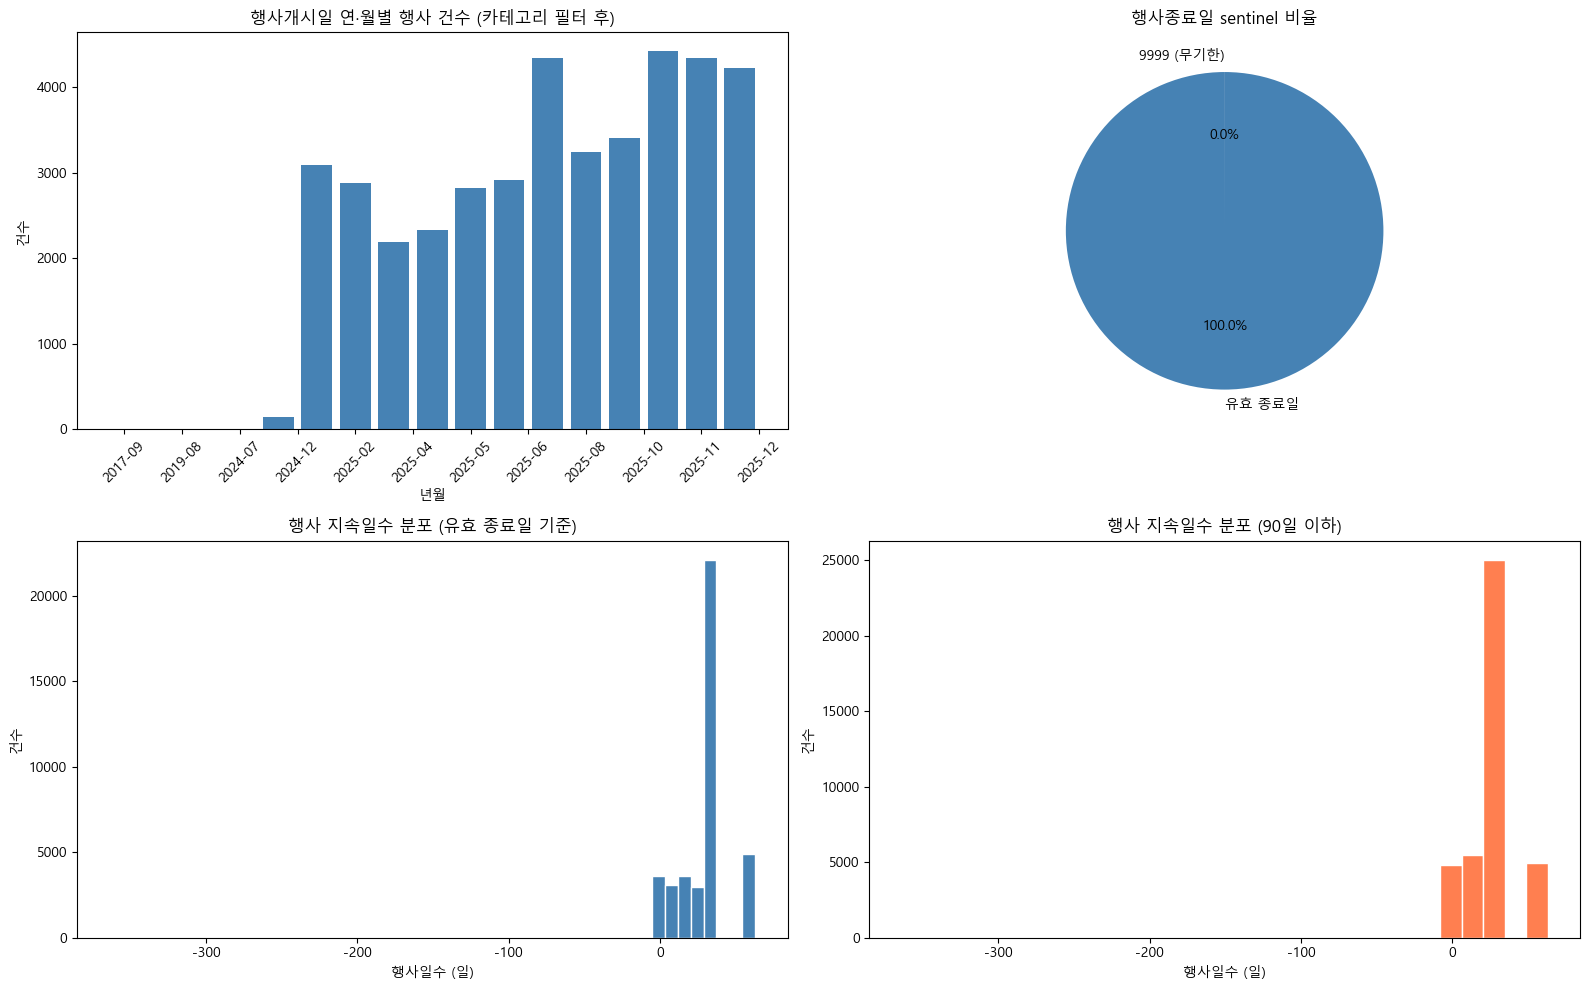


=== 행사 지속일수 기초 통계 (유효 종료일 기준, 카테고리 필터 후) ===
count    40304.000000
mean        27.474990
std         15.938513
min       -364.000000
25%         18.000000
50%         29.000000
75%         30.000000
max         63.000000
Name: 행사일수, dtype: float64


In [22]:
# 행사개시일 연·월 분포 (카테고리 필터링 후)
df_valid = df_filtered.filter(pl.col('행사종료일').dt.year() != 9999)
df_year_month = (
    df_filtered.with_columns([
        pl.col('행사개시일').dt.year().alias('년'),
        pl.col('행사개시일').dt.month().alias('월'),
    ])
    .group_by(['년', '월'])
    .agg(pl.len().alias('건수'))
    .sort(['년', '월'])
    .with_columns(
        (pl.col('년').cast(pl.String) + '-' + pl.col('월').cast(pl.String).str.zfill(2)).alias('년월')
    )
).to_pandas()

# 행사 지속일수 (sentinel 제외)
df_duration = df_valid.with_columns(
    (pl.col('행사종료일') - pl.col('행사개시일')).dt.total_days().alias('행사일수')
).to_pandas()

sentinel_n_f = df_filtered.filter(pl.col('행사종료일').dt.year() == 9999).shape[0]
total_f = df_filtered.shape[0]

# 시각화
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. 행사개시일 연월 추이
axes[0, 0].bar(df_year_month['년월'], df_year_month['건수'], color='steelblue')
axes[0, 0].set_title('행사개시일 연·월별 행사 건수 (카테고리 필터 후)')
axes[0, 0].set_xlabel('년월')
axes[0, 0].set_ylabel('건수')
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].xaxis.set_major_locator(ticker.MaxNLocator(15))

# 2. 9999 sentinel vs 유효 종료일 비율
axes[0, 1].pie(
    [sentinel_n_f, total_f - sentinel_n_f],
    labels=['9999 (무기한)', '유효 종료일'],
    autopct='%1.1f%%',
    colors=['tomato', 'steelblue'],
    startangle=90
)
axes[0, 1].set_title('행사종료일 sentinel 비율')

# 3. 행사 지속일수 분포 (전체)
axes[1, 0].hist(df_duration['행사일수'], bins=50, color='steelblue', edgecolor='white')
axes[1, 0].set_title('행사 지속일수 분포 (유효 종료일 기준)')
axes[1, 0].set_xlabel('행사일수 (일)')
axes[1, 0].set_ylabel('건수')

# 4. 행사 지속일수 분포 (90일 이하 확대)
short = df_duration[df_duration['행사일수'] <= 90]
axes[1, 1].hist(short['행사일수'], bins=30, color='coral', edgecolor='white')
axes[1, 1].set_title('행사 지속일수 분포 (90일 이하)')
axes[1, 1].set_xlabel('행사일수 (일)')
axes[1, 1].set_ylabel('건수')

plt.tight_layout()
plt.show()

# 지속일수 기초 통계
print("\n=== 행사 지속일수 기초 통계 (유효 종료일 기준, 카테고리 필터 후) ===")
print(df_duration['행사일수'].describe())


## 7-1. 행사 지속기간 심층 분석 (카테고리 필터 후)
- 지속일수 밀집 구간 및 최빈값 확인
- 장기 행사(상위 N건) 상품군 및 프로모션 타입 분석


In [23]:
# ── 1. 지속일수 밀집 구간 ─────────────────────────────────────────────────
mode_val = int(df_duration['행사일수'].mode()[0])
peak = (
    df_duration['행사일수']
    .value_counts()
    .sort_values(ascending=False)
    .head(10)
    .rename('건수')
    .reset_index()
    .rename(columns={'index': '행사일수'})
)
print(f"=== 지속일수 최빈값: {mode_val}일 ===")
print(peak.to_string(index=False))

# ── 2. 장기 행사 상위 30건 상품군 분석 ───────────────────────────────────
long_events = (
    df_valid
    .with_columns(
        (pl.col('행사종료일') - pl.col('행사개시일')).dt.total_days().alias('행사일수')
    )
    .sort('행사일수', descending=True)
    .head(30)
    .select(['상품코드', '상품코드_str', '프로모션_타입', '행사개시일', '행사종료일', '행사일수', '중분류명'])
)
print(f"\n=== 장기 행사 상위 30건 ===")
print(long_events.to_pandas().to_string(index=False))

# ── 3. 중분류별 평균·최대 지속일수 ───────────────────────────────────────
cat_duration = (
    df_valid
    .with_columns(
        (pl.col('행사종료일') - pl.col('행사개시일')).dt.total_days().alias('행사일수')
    )
    .group_by('중분류명')
    .agg([
        pl.col('행사일수').mean().round(1).alias('평균일수'),
        pl.col('행사일수').max().alias('최대일수'),
        pl.col('행사일수').median().alias('중앙값'),
        pl.len().alias('행사건수'),
    ])
    .sort('최대일수', descending=True)
)
print(f"\n=== 중분류별 행사 지속일수 (최대일수 기준 정렬) ===")
print(cat_duration.to_pandas().to_string(index=False))


=== 지속일수 최빈값: 30일 ===
 행사일수    건수
   30 13658
   29  8359
   60  3071
   27  2076
   14  1167
   61  1106
    2   919
   10   795
    6   668
    0   667

=== 장기 행사 상위 30건 ===
  상품코드 상품코드_str 프로모션_타입      행사개시일      행사종료일  행사일수 중분류명
122993   122993    구독행사 2025-02-26 2025-04-30    63 샌드위치
123059   123059    구독행사 2025-02-26 2025-04-30    63 샌드위치
123108   123108    구독행사 2025-02-26 2025-04-30    63  햄버거
123110   123110    구독행사 2025-02-26 2025-04-30    63  햄버거
105954   105954    구독행사 2025-02-26 2025-04-30    63  햄버거
106421   106421    구독행사 2025-02-26 2025-04-30    63 샌드위치
108514   108514    구독행사 2025-02-26 2025-04-30    63  햄버거
108601   108601    구독행사 2025-02-26 2025-04-30    63 샌드위치
108632   108632    구독행사 2025-02-26 2025-04-30    63 샌드위치
108657   108657    구독행사 2025-02-26 2025-04-30    63  햄버거
108726   108726    구독행사 2025-02-26 2025-04-30    63  햄버거
108760   108760    구독행사 2025-02-26 2025-04-30    63  햄버거
108802   108802    구독행사 2025-02-26 2025-04-30    63  햄버거
108862   108862    구독행사 20

구독행사 전체 건수: 4,948건 / 고유 상품: 623개

=== ① 중분류별 구독행사 coverage ===
 중분류명  구독_상품수  B4_전체상품수  coverage(%)
  도시락     112      2375          4.7
   와인      93      2088          4.5
 세븐카페      90      1210          7.4
 샌드위치      86      1778          4.8
   김밥      76      1311          5.8
  햄버거      75       804          9.3
 삼각김밥      54      1876          2.9
   양주      21      1038          2.0
    캔       6      1215          0.5
  흰우유       3       203          1.5
   주스       3      1039          0.3
 건해산물       2       666          0.3
스포츠음료       1       256          0.4
상온간편식       1       590          0.2

=== ② 구독행사 상품 × 타 프로모션 중복 참여 ===
구독행사 상품 중 타 프로모션 중복 참여: 418개 / 623개 (67.1%)
프로모션_타입  상품수  행사건수
   콤보할인  285  1508
   번들할인  168  4533
   콤보증정   66   100
   단품할인   18    40
    2+1    4     4
    1+1    3     3
 장바구니할인    1     1

=== ③ 구독행사 개시 월별 건수 ===
     년월  개시건수
2024-12   103
2025-01   140
2025-02   575
2025-04   236
2025-05   411
2025-06   247
2025-07   673
2025-08   269
2

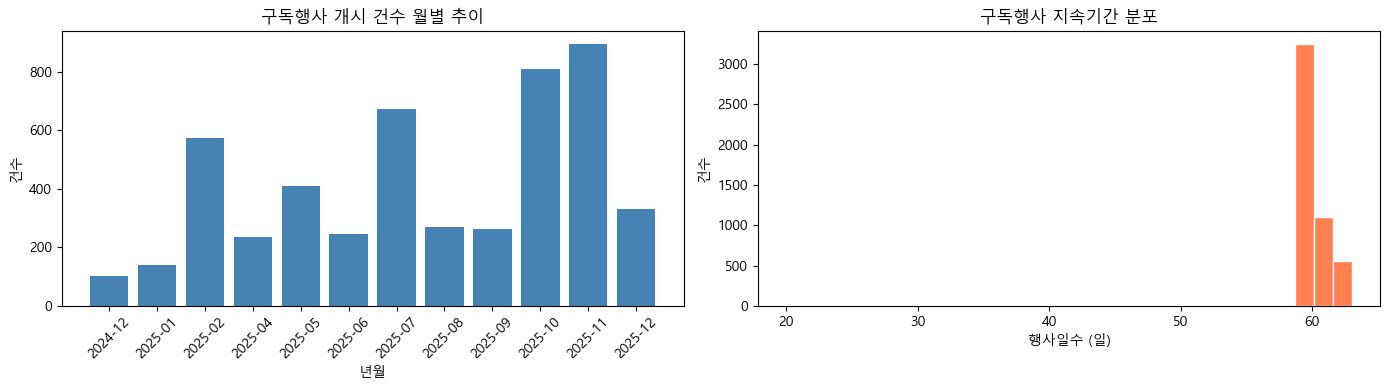

In [24]:
# ## 7-2. 구독행사 심층 분석
# ### 구독행사: 세븐카페/와인/도시락/샌드위치,햄버거/삼각김밥,김밥 카테고리 상품 1달간 진행
# - **① Coverage**: 중분류별 B4 전체 상품 수 대비 구독행사 참여 비율
# - **② 프로모션 중복**: 구독행사 상품이 다른 프로모션에도 동시 참여하는지
# - **③ 월별 시계열**: 구독행사 개시 건수의 월별 분포
# - **④ 지속기간 분포**: 구독행사 자체의 기간 분포

df_sub = df_filtered.filter(pl.col('프로모션_타입') == '구독행사')
print(f"구독행사 전체 건수: {df_sub.shape[0]:,}건 / 고유 상품: {df_sub['상품코드'].n_unique():,}개")

# ── ① 중분류별 Coverage (B4 전체 대비 구독행사 참여 비율) ─────────────────
print("\n=== ① 중분류별 구독행사 coverage ===")
sub_cat = (
    df_sub.group_by('중분류명')
    .agg(pl.col('상품코드').n_unique().alias('구독_상품수'))
)
b4_cat = (
    df_b4.group_by('중분류명')
    .agg(pl.col('상품코드').n_unique().alias('B4_전체상품수'))
)
coverage = (
    sub_cat.join(b4_cat, on='중분류명', how='left')
    .with_columns(
        (pl.col('구독_상품수') / pl.col('B4_전체상품수') * 100).round(1).alias('coverage(%)')
    )
    .sort('구독_상품수', descending=True)
)
print(coverage.to_pandas().to_string(index=False))

# ── ② 구독행사 상품의 다른 프로모션 중복 참여 ────────────────────────────
print("\n=== ② 구독행사 상품 × 타 프로모션 중복 참여 ===")
sub_codes = set(df_sub['상품코드'].to_list())
overlap = (
    df_filtered
    .filter(
        pl.col('상품코드').is_in(sub_codes) &
        (pl.col('프로모션_타입') != '구독행사')
    )
    .group_by('프로모션_타입')
    .agg(
        pl.col('상품코드').n_unique().alias('상품수'),
        pl.len().alias('행사건수')
    )
    .sort('상품수', descending=True)
)
overlap_codes = df_filtered.filter(
    pl.col('상품코드').is_in(sub_codes) & (pl.col('프로모션_타입') != '구독행사')
)['상품코드'].n_unique()
print(f"구독행사 상품 중 타 프로모션 중복 참여: {overlap_codes}개 / {len(sub_codes)}개 ({overlap_codes/len(sub_codes)*100:.1f}%)")
print(overlap.to_pandas().to_string(index=False))

# ── ③ 구독행사 개시 건수 월별 추이 ───────────────────────────────────────
print("\n=== ③ 구독행사 개시 월별 건수 ===")
sub_monthly = (
    df_sub
    .with_columns([
        pl.col('행사개시일').dt.year().alias('년'),
        pl.col('행사개시일').dt.month().alias('월'),
    ])
    .group_by(['년', '월'])
    .agg(pl.len().alias('개시건수'))
    .sort(['년', '월'])
    .with_columns(
        (pl.col('년').cast(pl.String) + '-' + pl.col('월').cast(pl.String).str.zfill(2)).alias('년월')
    )
).to_pandas()
print(sub_monthly[['년월', '개시건수']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(sub_monthly['년월'], sub_monthly['개시건수'], color='steelblue')
axes[0].set_title('구독행사 개시 건수 월별 추이')
axes[0].set_xlabel('년월')
axes[0].set_ylabel('건수')
axes[0].tick_params(axis='x', rotation=45)

# ── ④ 구독행사 지속기간 분포 ─────────────────────────────────────────────
print("\n=== ④ 구독행사 지속기간 분포 ===")
sub_valid = df_sub.filter(pl.col('행사종료일').dt.year() != 9999)
sub_dur = sub_valid.with_columns(
    (pl.col('행사종료일') - pl.col('행사개시일')).dt.total_days().alias('행사일수')
)['행사일수'].to_pandas()
print(sub_dur.describe().round(1))
peak_sub = sub_dur.value_counts().sort_values(ascending=False).head(5)
print(f"\n최빈 지속일수:\n{peak_sub.rename('건수').reset_index().rename(columns={'index':'일수'}).to_string(index=False)}")

axes[1].hist(sub_dur, bins=30, color='coral', edgecolor='white')
axes[1].set_title('구독행사 지속기간 분포')
axes[1].set_xlabel('행사일수 (일)')
axes[1].set_ylabel('건수')

plt.tight_layout()
plt.show()


### 7-1-2. 정규화 행사명 기준 실제 운영일수 분석
- `행사명_norm` 기준으로 동일 프로모션의 여러 구간을 하나로 묶어 집계
- **총운영일수**: 구간 합산 (월 사이 공백 제외)
- **전체스팬**: 첫 개시일 ~ 마지막 종료일 (공백 포함)
- 위 7-1-1의 원본 분석(월별 단위)과 비교하여 장기 운영 프로모션 식별

정규화 후 고유 행사명: 5031개
총운영일수 중앙값: 31일 / 평균: 46일

=== 장기 운영 Top 30 (구간 합산 기준) ===
                  행사명_norm   중분류명 프로모션_타입      최초개시일      최종종료일  구간수  총운영일수  전체스팬
  풀무원)액티비아스무디딸기바나나150ml1+1   요구르트     1+1 2025-01-01 2025-12-31   12    365   365
         롯데)롤만두[쫄깃/김치] 2+1   냉동만두     2+1 2025-01-01 2025-12-31   24    365   365
      PB)오구딸기타임200ml외1종1+1   가공우유     1+1 2025-01-01 2025-12-31   26    365   365
     비락)유기농야채사랑190ml외1종2+1   냉장주스     2+1 2025-01-01 2025-12-31   24    365   365
      대상)안주야소곱창볶음한판200g 할인   조리냉동    단품할인 2025-01-01 2025-12-31   12    365   365
          오뚜기)오뚜기밥210g 2+1  가공미반류     2+1 2025-01-01 2025-12-31   12    365   365
         풀무원)그릭시그니처150g1+1   요구르트     1+1 2025-01-01 2025-12-31   12    365   365
           남양)초코에몽250ml2+1   가공우유     2+1 2025-01-01 2025-12-31   12    365   365
        서울)딸기우유300ml외3종2+1   가공우유     2+1 2025-01-01 2025-12-31   48    365   365
        CJ)맥스봉치즈플러스55g 2+1   냉장간식     2+1 2025-01-01 2025-12-31   12    365   365
       오뚜기)오뚜기밥210g*

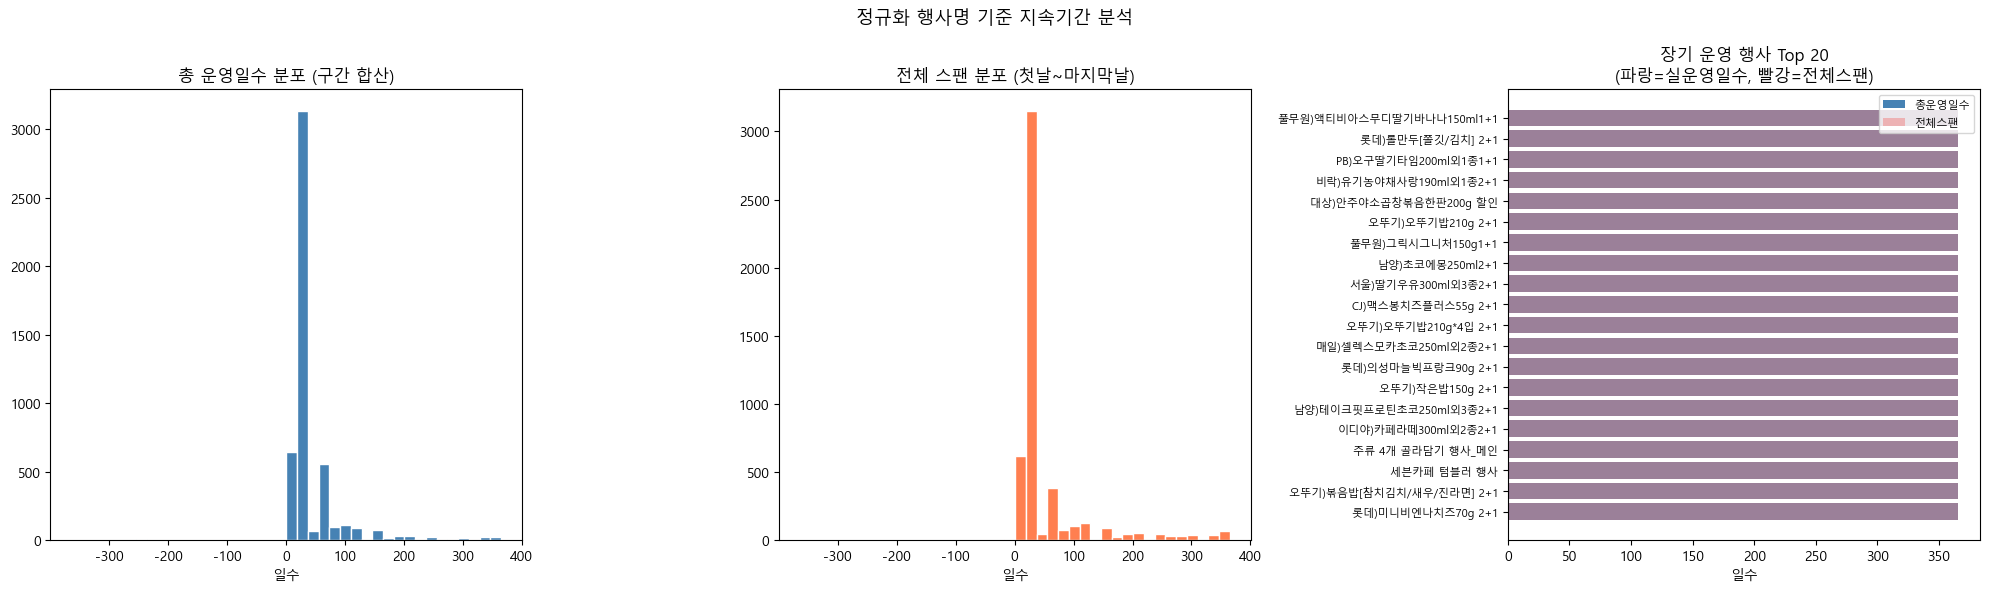

In [25]:
df_intervals = (
    df_filtered
    .filter(pl.col('행사종료일').dt.year() != 9999)
    .group_by('행사명_norm')
    .agg([
        pl.col('행사개시일').alias('시작목록'),
        pl.col('행사종료일').alias('종료목록'),
        pl.col('중분류명').first().alias('중분류명'),
        pl.col('프로모션_타입').first().alias('프로모션_타입'),
    ])
    .to_pandas()
)

def sum_interval_days(starts, ends):
    intervals = sorted(zip(
        [pd.Timestamp(s) for s in starts],
        [pd.Timestamp(e) for e in ends],
    ))
    cur_s, cur_e = intervals[0]
    total = 0
    for s, e in intervals[1:]:
        if s <= cur_e + pd.Timedelta(days=1):
            cur_e = max(cur_e, e)
        else:
            total += (cur_e - cur_s).days + 1
            cur_s, cur_e = s, e
    total += (cur_e - cur_s).days + 1
    return total

df_intervals['총운영일수'] = df_intervals.apply(
    lambda r: sum_interval_days(r['시작목록'], r['종료목록']), axis=1
)
df_intervals['전체스팬'] = df_intervals.apply(
    lambda r: (pd.Timestamp(max(r['종료목록'])) - pd.Timestamp(min(r['시작목록']))).days + 1, axis=1
)
df_intervals['최초개시일'] = df_intervals['시작목록'].apply(
    lambda x: pd.Timestamp(min(x)).strftime('%Y-%m-%d')
)
df_intervals['최종종료일'] = df_intervals['종료목록'].apply(
    lambda x: pd.Timestamp(max(x)).strftime('%Y-%m-%d')
)
df_intervals['구간수'] = df_intervals['시작목록'].apply(len)

df_norm_dur = (
    df_intervals[['행사명_norm', '중분류명', '프로모션_타입',
                  '최초개시일', '최종종료일', '구간수', '총운영일수', '전체스팬']]
    .sort_values('총운영일수', ascending=False)
    .reset_index(drop=True)
)

print(f"정규화 후 고유 행사명: {len(df_norm_dur)}개")
print(f"총운영일수 중앙값: {df_norm_dur['총운영일수'].median():.0f}일 / 평균: {df_norm_dur['총운영일수'].mean():.0f}일\n")

print("=== 장기 운영 Top 30 (구간 합산 기준) ===")
print(df_norm_dur.head(30).to_string(index=False))

# 분포 시각화 + 장기 행사 바차트
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].hist(df_norm_dur['총운영일수'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('총 운영일수 분포 (구간 합산)')
axes[0].set_xlabel('일수')

axes[1].hist(df_norm_dur['전체스팬'], bins=40, color='coral', edgecolor='white')
axes[1].set_title('전체 스팬 분포 (첫날~마지막날)')
axes[1].set_xlabel('일수')

top20 = df_norm_dur.head(20)
labels = [n[:25] + '…' if len(n) > 25 else n for n in top20['행사명_norm']]
axes[2].barh(range(len(top20)), top20['총운영일수'], color='steelblue', label='총운영일수')
axes[2].barh(range(len(top20)), top20['전체스팬'], color='lightcoral', alpha=0.5, label='전체스팬')
axes[2].set_yticks(range(len(top20)))
axes[2].set_yticklabels(labels, fontsize=8)
axes[2].invert_yaxis()
axes[2].set_title('장기 운영 행사 Top 20\n(파랑=실운영일수, 빨강=전체스팬)')
axes[2].set_xlabel('일수')
axes[2].legend(fontsize=8)

plt.suptitle('정규화 행사명 기준 지속기간 분석', fontsize=13)
plt.tight_layout()
plt.show()


## 8. 프로모션 × 카테고리 교차 분석
- 어떤 중분류가 어떤 프로모션 타입을 주로 사용하는지 파악
- HIN [상품→프로모션] 엣지 가중치 설계 근거

크로스탭 shape: (62, 15)  (중분류 x 프로모션_타입)
중분류명
와인        411.0
노벨티       371.0
캔디류       367.0
초콜릿       317.0
스낵류       281.0
비스킷류      275.0
기능성드링크    274.0
냉장간식      265.0
용기면       241.0
도시락       220.0
Name: 상품수_합계, dtype: float64


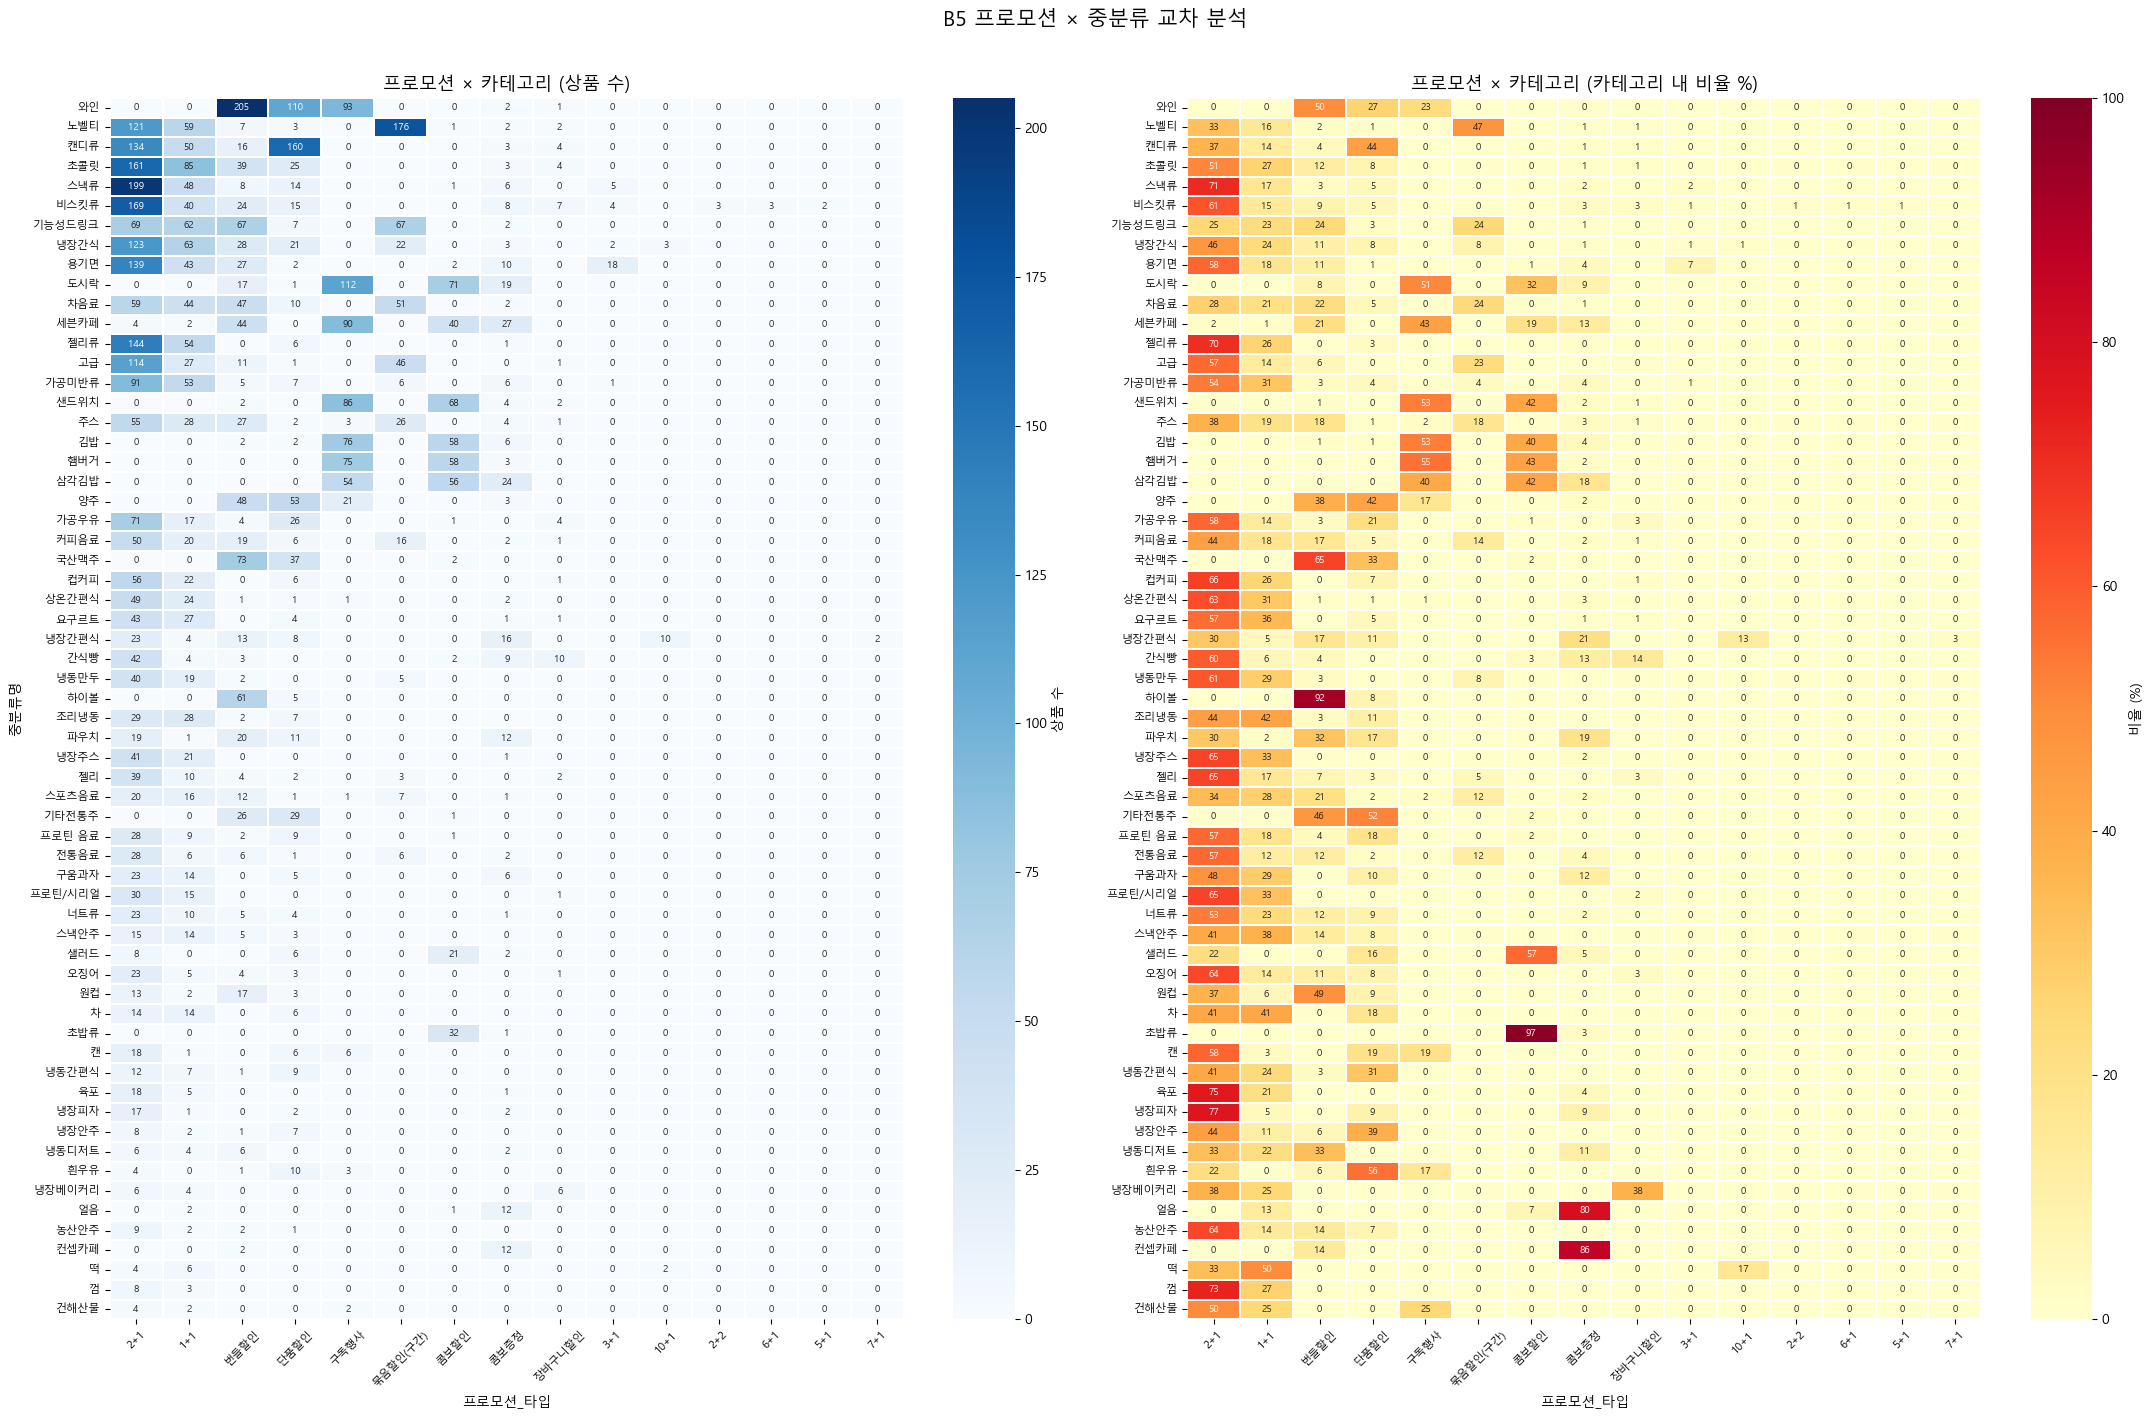

=== 프로모션 타입별 주력 중분류 Top5 ===
[2+1]
  스낵류: 199개
  비스킷류: 169개
  초콜릿: 161개
  젤리류: 144개
  용기면: 139개
[1+1]
  초콜릿: 85개
  냉장간식: 63개
  기능성드링크: 62개
  노벨티: 59개
  젤리류: 54개
[번들할인]
  와인: 205개
  국산맥주: 73개
  기능성드링크: 67개
  하이볼: 61개
  양주: 48개
[단품할인]
  캔디류: 160개
  와인: 110개
  양주: 53개
  국산맥주: 37개
  기타전통주: 29개
[구독행사]
  도시락: 112개
  와인: 93개
  세븐카페: 90개
  샌드위치: 86개
  김밥: 76개
[묶음할인(구간)]
  노벨티: 176개
  기능성드링크: 67개
  차음료: 51개
  고급: 46개
  주스: 26개
[콤보할인]
  도시락: 71개
  샌드위치: 68개
  김밥: 58개
  햄버거: 58개
  삼각김밥: 56개
[콤보증정]
  세븐카페: 27개
  삼각김밥: 24개
  도시락: 19개
  냉장간편식: 16개
  컨셉카페: 12개


In [26]:
# 1. 중분류 x 프로모션_타입 크로스탭 (상품 기준 unique count)
cross = (
    df_filtered
    .group_by(['중분류명', '프로모션_타입'])
    .agg(pl.col('상품코드').n_unique().alias('상품수'))
    .sort(['중분류명', '프로모션_타입'])
)

# pivot: 행=중분류명, 열=프로모션_타입
pivot = (
    cross.to_pandas()
    .pivot(index='중분류명', columns='프로모션_타입', values='상품수')
    .fillna(0)
)

# 중분류별 행 합계 기준 정렬 (행사 참여 상품 많은 순)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

# 열: 전체 합계 많은 프로모션 순 정렬
pivot = pivot[pivot.sum(axis=0).sort_values(ascending=False).index]

print(f"크로스탭 shape: {pivot.shape}  (중분류 x 프로모션_타입)")
print(pivot.sum(axis=1).head(10).rename('상품수_합계'))

# 2. 행 정규화 (각 카테고리 내 프로모션 비율)
pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

# 3. 시각화
fig, axes = plt.subplots(1, 2, figsize=(22, 14))

# 좌: 절대값 (상품 수)
sns.heatmap(
    pivot,
    ax=axes[0],
    cmap='Blues',
    linewidths=0.3,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': '상품 수'},
)
axes[0].set_title('프로모션 × 카테고리 (상품 수)', fontsize=13)
axes[0].set_xlabel('프로모션_타입')
axes[0].set_ylabel('중분류명')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', labelsize=8)

# 우: 행 정규화 (카테고리 내 프로모션 비율 %)
sns.heatmap(
    pivot_norm,
    ax=axes[1],
    cmap='YlOrRd',
    linewidths=0.3,
    annot=True,
    fmt='.0f',
    annot_kws={'size': 7},
    cbar_kws={'label': '비율 (%)'},
    vmin=0, vmax=100,
)
axes[1].set_title('프로모션 × 카테고리 (카테고리 내 비율 %)', fontsize=13)
axes[1].set_xlabel('프로모션_타입')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].tick_params(axis='y', labelsize=8)

plt.suptitle('B5 프로모션 × 중분류 교차 분석', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

# 4. 프로모션_타입별 주력 카테고리 Top5
print("=== 프로모션 타입별 주력 중분류 Top5 ===")
for promo in pivot.sum(axis=0).index[:8]:
    top5 = pivot[promo].sort_values(ascending=False).head(5)
    top5 = top5[top5 > 0]
    if len(top5) == 0:
        continue
    print(f"[{promo}]")
    for cat, cnt in top5.items():
        print(f"  {cat}: {int(cnt)}개")


## 8-1. 프로모션 타입 심화 분석
- **묶음할인·콤보할인·콤보증정·장바구니할인**: 중분류 및 상품 집중도
- **3+1, 10+1, 2+2, 6+1, 5+1, 7+1**: 행사명 직접 확인


=== ① 타입별 기본 현황 ===
프로모션_타입  행사건수  고유상품수
   콤보할인  2002    416
   콤보증정   506    223
 장바구니할인   310     49

=== 중분류 × 프로모션_타입 (상품수 기준) ===

[콤보할인] 상위 10개 중분류
중분류명  상품수
 도시락   71
샌드위치   68
 햄버거   58
  김밥   58
삼각김밥   56
세븐카페   40
 초밥류   32
 샐러드   21
국산맥주    2
 용기면    2

[콤보증정] 상위 10개 중분류
 중분류명  상품수
 세븐카페   27
 삼각김밥   24
  도시락   19
냉장간편식   16
 컨셉카페   12
  파우치   12
   얼음   12
  용기면   10
  간식빵    9
 비스킷류    8

[장바구니할인] 상위 10개 중분류
  중분류명  상품수
   간식빵   10
  비스킷류    7
냉장베이커리    6
   캔디류    4
   초콜릿    4
  가공우유    4
    젤리    2
  샌드위치    2
   노벨티    2
    와인    1


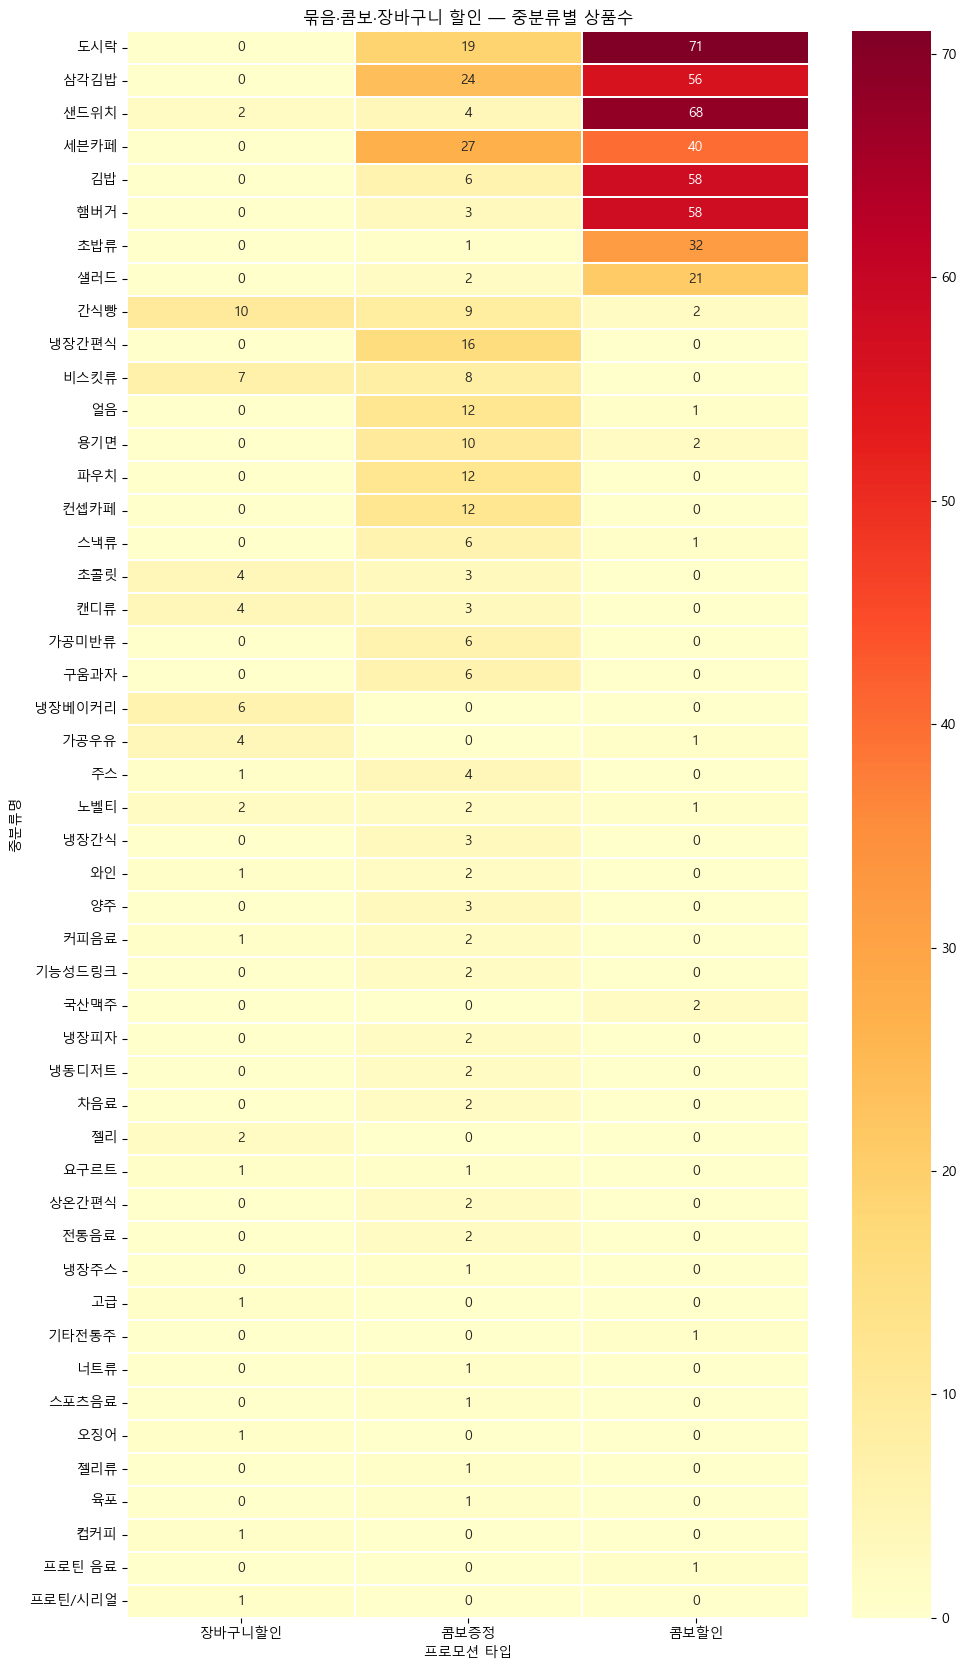


=== ② 번들 프로모션 타입별 행사명 ===

[3+1] 행사명 (18종)
                     행사명  건수
오뚜기)컵누들매콤한맛(소컵) 외 4종 3+1   5
             포키 4종 3+1행사   4
   오뚜기)진라면순한맛큰컵 외 2종 3+1   3
       농심)신라면소컵 외 2종 3+1   3
      투데이)엄지닭라면스낵20입 3+1   2
 농심)육개장사발면 외 1개 3+1_0317   2
      G)마루짱유부우동/튀김소바 3+1   2
   오뚜기)진라면순한맛소컵 외 1개 3+1   2
      농심)육개장사발면 외 1종 3+1   2
      농심)육개장사발면 외 1개 3+1   2
   오뚜기)진라면순한맛소컵 외 1종 3+1   2
  투데이)엄지닭라면스낵20g(낱개) 3+1   2
    쟌슨빌 프리미엄 혼합 선물세트 3+1   1
            농심)매운새우깡 3+1   1
     쟌슨빌 프리미엄 소시지 세트 3+1   1
            농심)신라면소컵 3+1   1
PB)박은영셰프의유산슬탕면큰컵 3+1 행사    1
      PB)우리쌀사골떡국163g 3+1   1

[10+1] 행사명 (14종)
                       행사명  건수
            25설)앙빵 2종 10+1   2
           삼진어묵프리미엄세트 10+1   1
       존쿡프리미엄수제델리미트세트 10+1   1
    존쿡 프리미엄 수제델리미트 세트 10+1   1
      맛의명태자 시그니처 명란세트 10+1   1
      존쿡 델리미트 시그니처 세트 10+1   1
  천하일미 이원일&홍석천 떡갈비 세트 10+1   1
        삼진어묵 어묵선물세트 美 10+1   1
       예소담 특포기김치 10kg 10+1   1
         삼진어묵1953세트1호 10+1   1
맛의명태자 시그니처 명란/젓갈 혼합세트 10+1   1
           몽탄우대

In [27]:
# ── ① 묶음할인·콤보할인·콤보증정·장바구니할인 집중도 ─────────────────────
target_types = ['묶음할인', '콤보할인', '콤보증정', '장바구니할인']
df_target = df_filtered.filter(pl.col('프로모션_타입').is_in(target_types))

print("=== ① 타입별 기본 현황 ===")
print(
    df_target.group_by('프로모션_타입')
    .agg([
        pl.len().alias('행사건수'),
        pl.col('상품코드').n_unique().alias('고유상품수'),
    ])
    .sort('행사건수', descending=True)
    .to_pandas().to_string(index=False)
)

print("\n=== 중분류 × 프로모션_타입 (상품수 기준) ===")
cat_cross = (
    df_target
    .group_by(['프로모션_타입', '중분류명'])
    .agg(pl.col('상품코드').n_unique().alias('상품수'))
    .sort(['프로모션_타입', '상품수'], descending=[False, True])
).to_pandas()

for ptype in target_types:
    sub = cat_cross[cat_cross['프로모션_타입'] == ptype].head(10)
    if sub.empty:
        continue
    print(f"\n[{ptype}] 상위 10개 중분류")
    print(sub[['중분류명', '상품수']].to_string(index=False))

# 히트맵: 4개 타입 × 중분류 (상품수)
pivot_t = (
    cat_cross
    .pivot(index='중분류명', columns='프로모션_타입', values='상품수')
    .fillna(0)
)
pivot_t = pivot_t.loc[pivot_t.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_t) * 0.35)))
sns.heatmap(
    pivot_t, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.3, ax=ax
)
ax.set_title('묶음·콤보·장바구니 할인 — 중분류별 상품수')
ax.set_xlabel('프로모션 타입')
ax.set_ylabel('중분류명')
plt.tight_layout()
plt.show()

# ── ② 3+1·10+1·2+2·6+1·5+1·7+1 행사명 확인 ─────────────────────────────
bundle_types = ['3+1', '10+1', '2+2', '6+1', '5+1', '7+1']
df_bundle = df_filtered.filter(pl.col('프로모션_타입').is_in(bundle_types))

print("\n=== ② 번들 프로모션 타입별 행사명 ===")
for ptype in bundle_types:
    names = (
        df_bundle
        .filter(pl.col('프로모션_타입') == ptype)
        .group_by('행사명')
        .agg(pl.len().alias('건수'))
        .sort('건수', descending=True)
    )
    if names.shape[0] == 0:
        print(f"\n[{ptype}] 해당 행사 없음")
        continue
    print(f"\n[{ptype}] 행사명 ({names.shape[0]}종)")
    print(names.to_pandas().to_string(index=False))


## 8-2. 묶음·콤보·장바구니 할인 — 상품군 공동 출현 분석
- 같은 행사명에 묶인 상품들의 중분류 조합(co-occurrence) 파악
- 어떤 카테고리 쌍이 함께 자주 엮이는지 확인


### 8-2-0. 행사명 시기 패턴 탐색
- `N월`, `NN년 N월`, `(N)` 등 시기 관련 접두/접미사 포함 행사명 샘플 확인
- 정규화 전 패턴 파악용 탐색 셀 (월별로 분리된 동일 행사 식별)

In [28]:
# 행사명 패턴 탐색 — 시기별로 분리된 동일 행사 확인
import re

target_types = ['묶음할인', '콤보할인', '콤보증정', '장바구니할인']
event_names = (
    df_filtered
    .filter(pl.col('프로모션_타입').is_in(target_types))
    .select('행사명')
    .unique()
    .sort('행사명')
    ['행사명']
    .to_list()
)

# 숫자·월·년도·기간 패턴이 포함된 행사명 샘플 출력
patterns = re.compile(r'(\d{4}|\d{1,2}월|\d+차|\d+회|\(|\[)')
matched = [n for n in event_names if patterns.search(str(n))][:60]
print(f'시기 관련 패턴 포함 행사명 샘플 ({len(matched)}개 발췌):\n')
for n in matched:
    print(' ', n)


시기 관련 패턴 포함 행사명 샘플 (60개 발췌):

  10월 삼립)뉴욕식베이글샐러드박스 2종 PB생수 증정 행사
  10월 세븐카페 텀블러 행사
  10월 소프트콘 6종 구매시 오리온)초코파이2입 증정
  10월 치맥 행사
  10월 치맥 행사 (2)
  11월 세븐카페 텀블러 행사
  11월 소프트콘 6종 구매시 오리온)미쯔미니700 증정 행사
  11월 치맥행사
  12월 세븐카페 텀블러 행사
  12월 소프트콘 6종 구매시 오리온)통크1200 증정 행사
  12월 치맥행사 (1)
  12월 치맥행사 (2)
  1월 군고구마 닥터유단백질프로250ml 콤보행사
  1월 맥주 콤보 할인 행사
  1월 세븐카페 텀블러 행사
  1월 소프트콘 2종(명인딸기 컵/콘) 구매 시 크라운)죠리퐁핑크퐁마시멜로 증정 행사
  1월과자_ 롯데)칸쵸컵2700 증정행사
  25년 12월 딸기페어 NH농협카드 20% 할인
  25년 12월 딸기페어 카카오페이머니 20% 할인
  25년 1월 빵 4종 2봉 이상 네이버페이 결제 시 50% 할인
  2월 군고구마 닥터유단백질프로250ml 콤보행사
  2월 맥주 번들 콤보 할인 행사
  2월 세븐카페 텀블러 행사
  2월 소프트콘 6종 구매 시 해태)크림웨하스, 딸기웨스 증정 행사
  3월 세븐카페 텀블러 행사
  3월 소프트콘 6종 구매시 롯데)ABC초코쿠키 증정 행사
  4월 세븐카페 텀블러 행사
  4월 소프트콘 4종 구매시 오리온)미쯔미니700 증정 행사
  5월 델몬트퍼플레몬에이드제로 구매 시 꽃모양얼음컵 증정 행사
  5월 세븐카페 텀블러 행사
  5월 소프트콘 6종 구매시 해태)구운고구마27g 증정 행사
  6월 세븐카페 만쥬 2종 콤보행사
  6월 세븐카페 텀블러 행사
  6월 소프트콘 6종 구매시 오리온)미쯔미니700 증정 행사
  6월 치맥 콤보 할인 행사
  7월 세븐카페 ICE레귤러/라지 만쥬 2종 증정
  7월 세븐카페 텀블러 행사
  7월 소프트콘 6종 구매시 크라운)마이쮸리치44g 증정 행사
  7월 치맥 

### 8-2-1. 4개 타입 합산 중분류 공동출현 히트맵
- 묶음할인·콤보할인·콤보증정·장바구니할인을 타입별로 각각 카운트 후 합산
- 같은 행사명(`행사명_norm`)에 함께 등장한 중분류 쌍 수 집계
- 셀 값 = 해당 중분류 쌍이 공동 등장한 행사 수 (4개 타입 합계)
- 히트맵 아래 빈도 오름차순 테이블 출력

중분류 수: 43개 | 총 조합 쌍 수: 146개


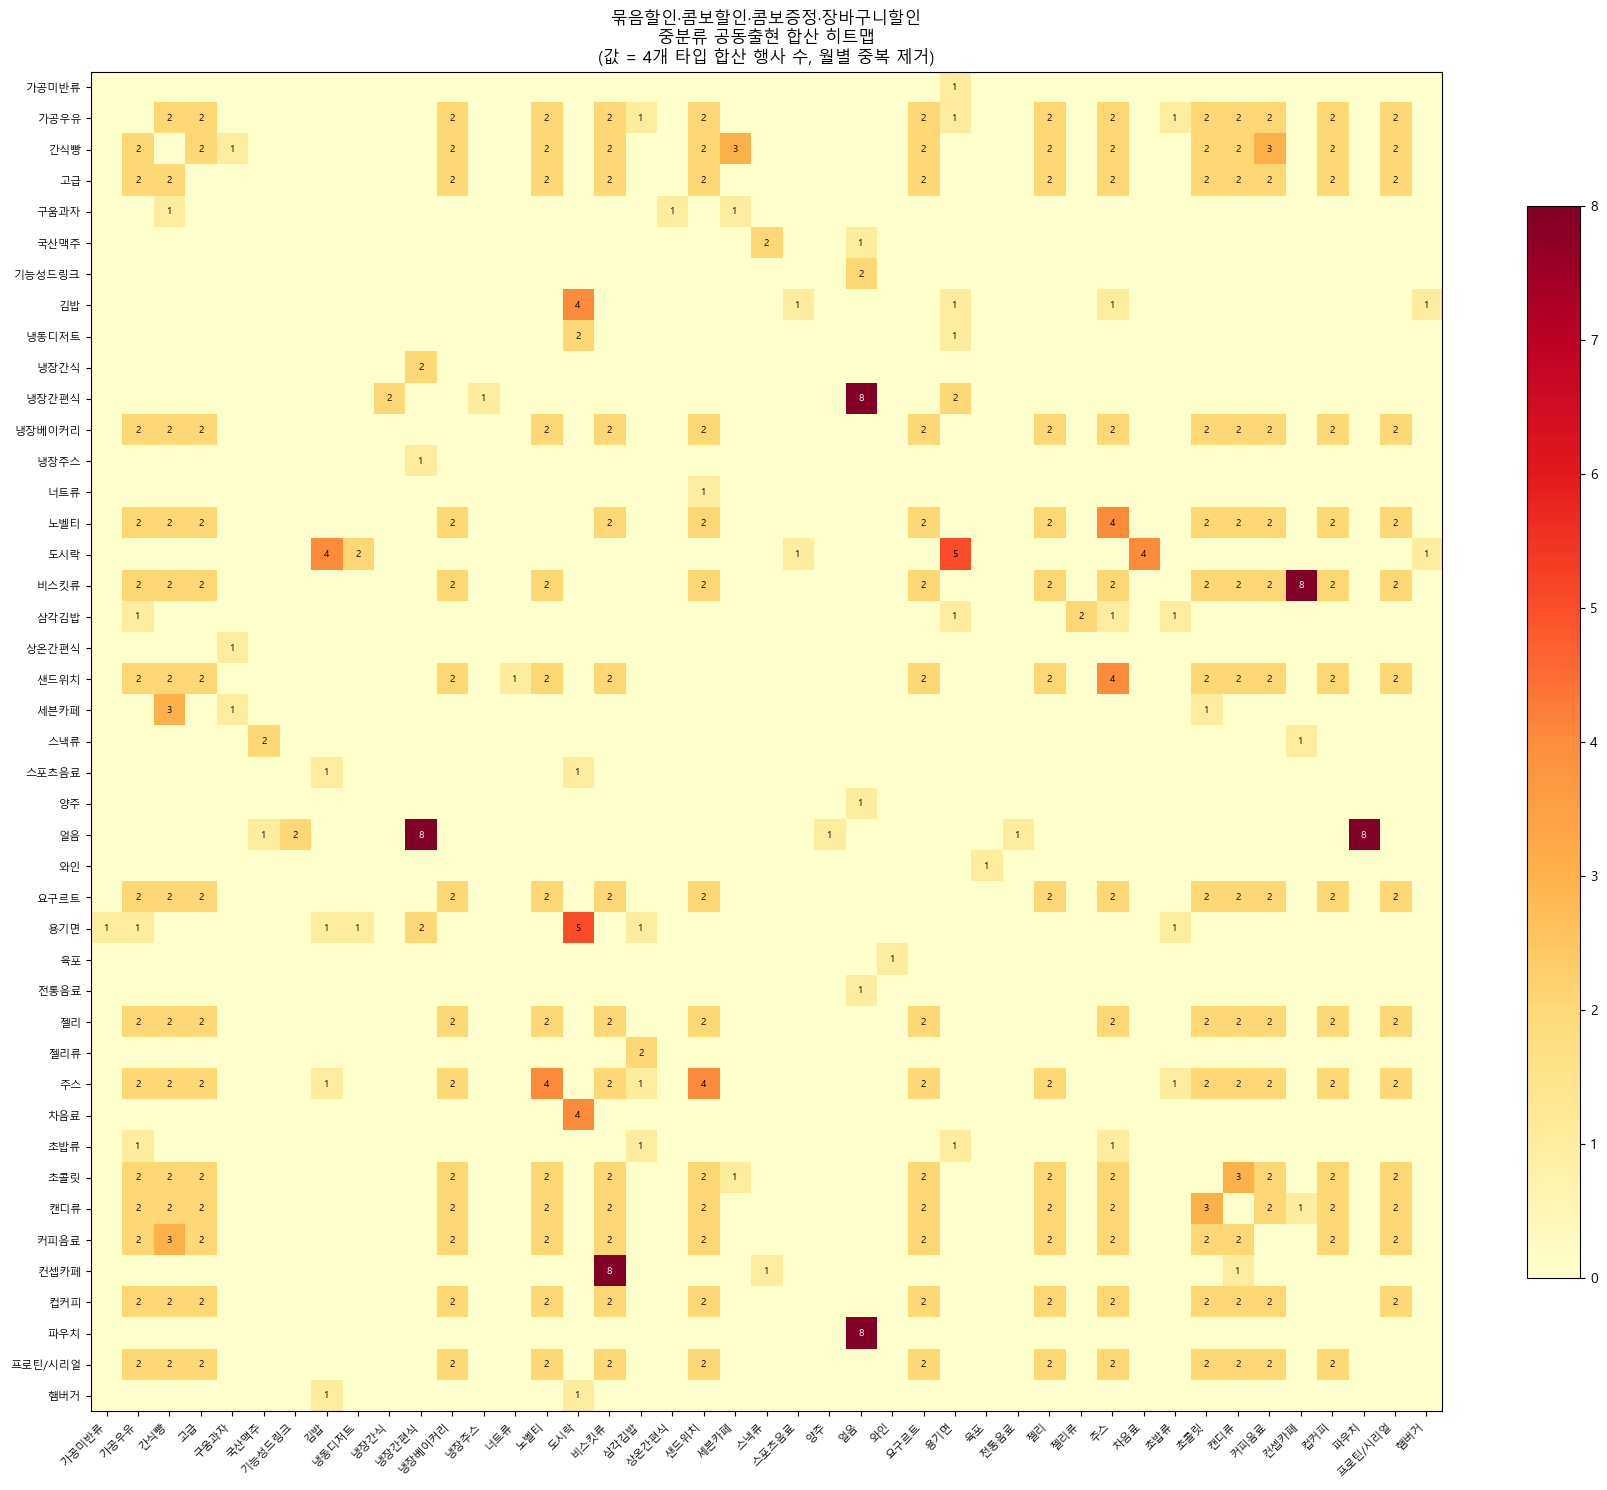


총 146개 조합 (0 제외)

 중분류_A   중분류_B  공동출현_행사수
  가공우유    삼각김밥         1
  가공우유     용기면         1
  가공우유     초밥류         1
  삼각김밥     용기면         1
   용기면     초밥류         1
  삼각김밥     초밥류         1
    양주      얼음         1
  국산맥주      얼음         1
    김밥     햄버거         1
   도시락     햄버거         1
    김밥   스포츠음료         1
   도시락   스포츠음료         1
  구움과자   상온간편식         1
   너트류    샌드위치         1
    얼음    전통음료         1
  구움과자    세븐카페         1
    주스     초밥류         1
  삼각김밥      주스         1
    와인      육포         1
   스낵류    컨셉카페         1
    김밥      주스         1
  세븐카페     초콜릿         1
   간식빵    구움과자         1
 냉장간편식    냉장주스         1
   캔디류    컨셉카페         1
 냉동디저트     용기면         1
 가공미반류     용기면         1
    김밥     용기면         1
  국산맥주     스낵류         2
 냉장간편식     용기면         2
  삼각김밥     젤리류         2
  냉장간식   냉장간편식         2
  가공우유    커피음료         2
  가공우유    비스킷류         2
  가공우유    샌드위치         2
  가공우유    요구르트         2
  가공우유      젤리         2
  가공우유      주스         2
  가공우유

In [29]:
from itertools import combinations
from collections import Counter
import numpy as np

target_types = ['묶음할인', '콤보할인', '콤보증정', '장바구니할인']

total_counter = Counter()
for ptype in target_types:
    df_p = df_filtered.filter(pl.col('프로모션_타입') == ptype)
    event_cats_p = (
        df_p
        .group_by('행사명_norm')
        .agg(pl.col('중분류명').drop_nulls().unique().alias('중분류_목록'))
        .filter(pl.col('중분류_목록').list.len() >= 2)
    ).to_pandas()
    for cats in event_cats_p['중분류_목록']:
        for pair in combinations(sorted(cats), 2):
            total_counter[pair] += 1

all_cats = sorted(set(c for pair in total_counter for c in pair))
n = len(all_cats)
cat_idx = {c: i for i, c in enumerate(all_cats)}
print(f'중분류 수: {n}개 | 총 조합 쌍 수: {len(total_counter)}개')

matrix = np.zeros((n, n), dtype=int)
for (a, b), cnt in total_counter.items():
    i, j = cat_idx[a], cat_idx[b]
    matrix[i, j] = cnt
    matrix[j, i] = cnt

fig, ax = plt.subplots(figsize=(18, 15))
im = ax.imshow(matrix, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(all_cats, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(all_cats, fontsize=8)
for i in range(n):
    for j in range(n):
        if matrix[i, j] > 0:
            ax.text(j, i, str(matrix[i, j]),
                    ha='center', va='center', fontsize=7,
                    color='black' if matrix[i, j] < matrix.max() * 0.7 else 'white')
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title(
    '묶음할인·콤보할인·콤보증정·장바구니할인\n중분류 공동출현 합산 히트맵\n(값 = 4개 타입 합산 행사 수, 월별 중복 제거)',
    fontsize=12
)
plt.tight_layout()
plt.show()

pair_df = (
    pd.DataFrame(
        [(a, b, cnt) for (a, b), cnt in total_counter.items() if cnt > 0],
        columns=['중분류_A', '중분류_B', '공동출현_행사수']
    )
    .sort_values('공동출현_행사수', ascending=True)
    .reset_index(drop=True)
)
print(f'\n총 {len(pair_df)}개 조합 (0 제외)\n')
print(pair_df.to_string(index=False))


### 8-2-2. 타입별 중분류 공동출현 히트맵
- 묶음할인·콤보할인·콤보증정·장바구니할인 각각의 히트맵을 2×2로 배치
- 해당 타입에서 실제 공동출현한 중분류만 축으로 표시 (0 쌍 제외)
- `행사명_norm` 기준 집계 (월별 중복 제거)

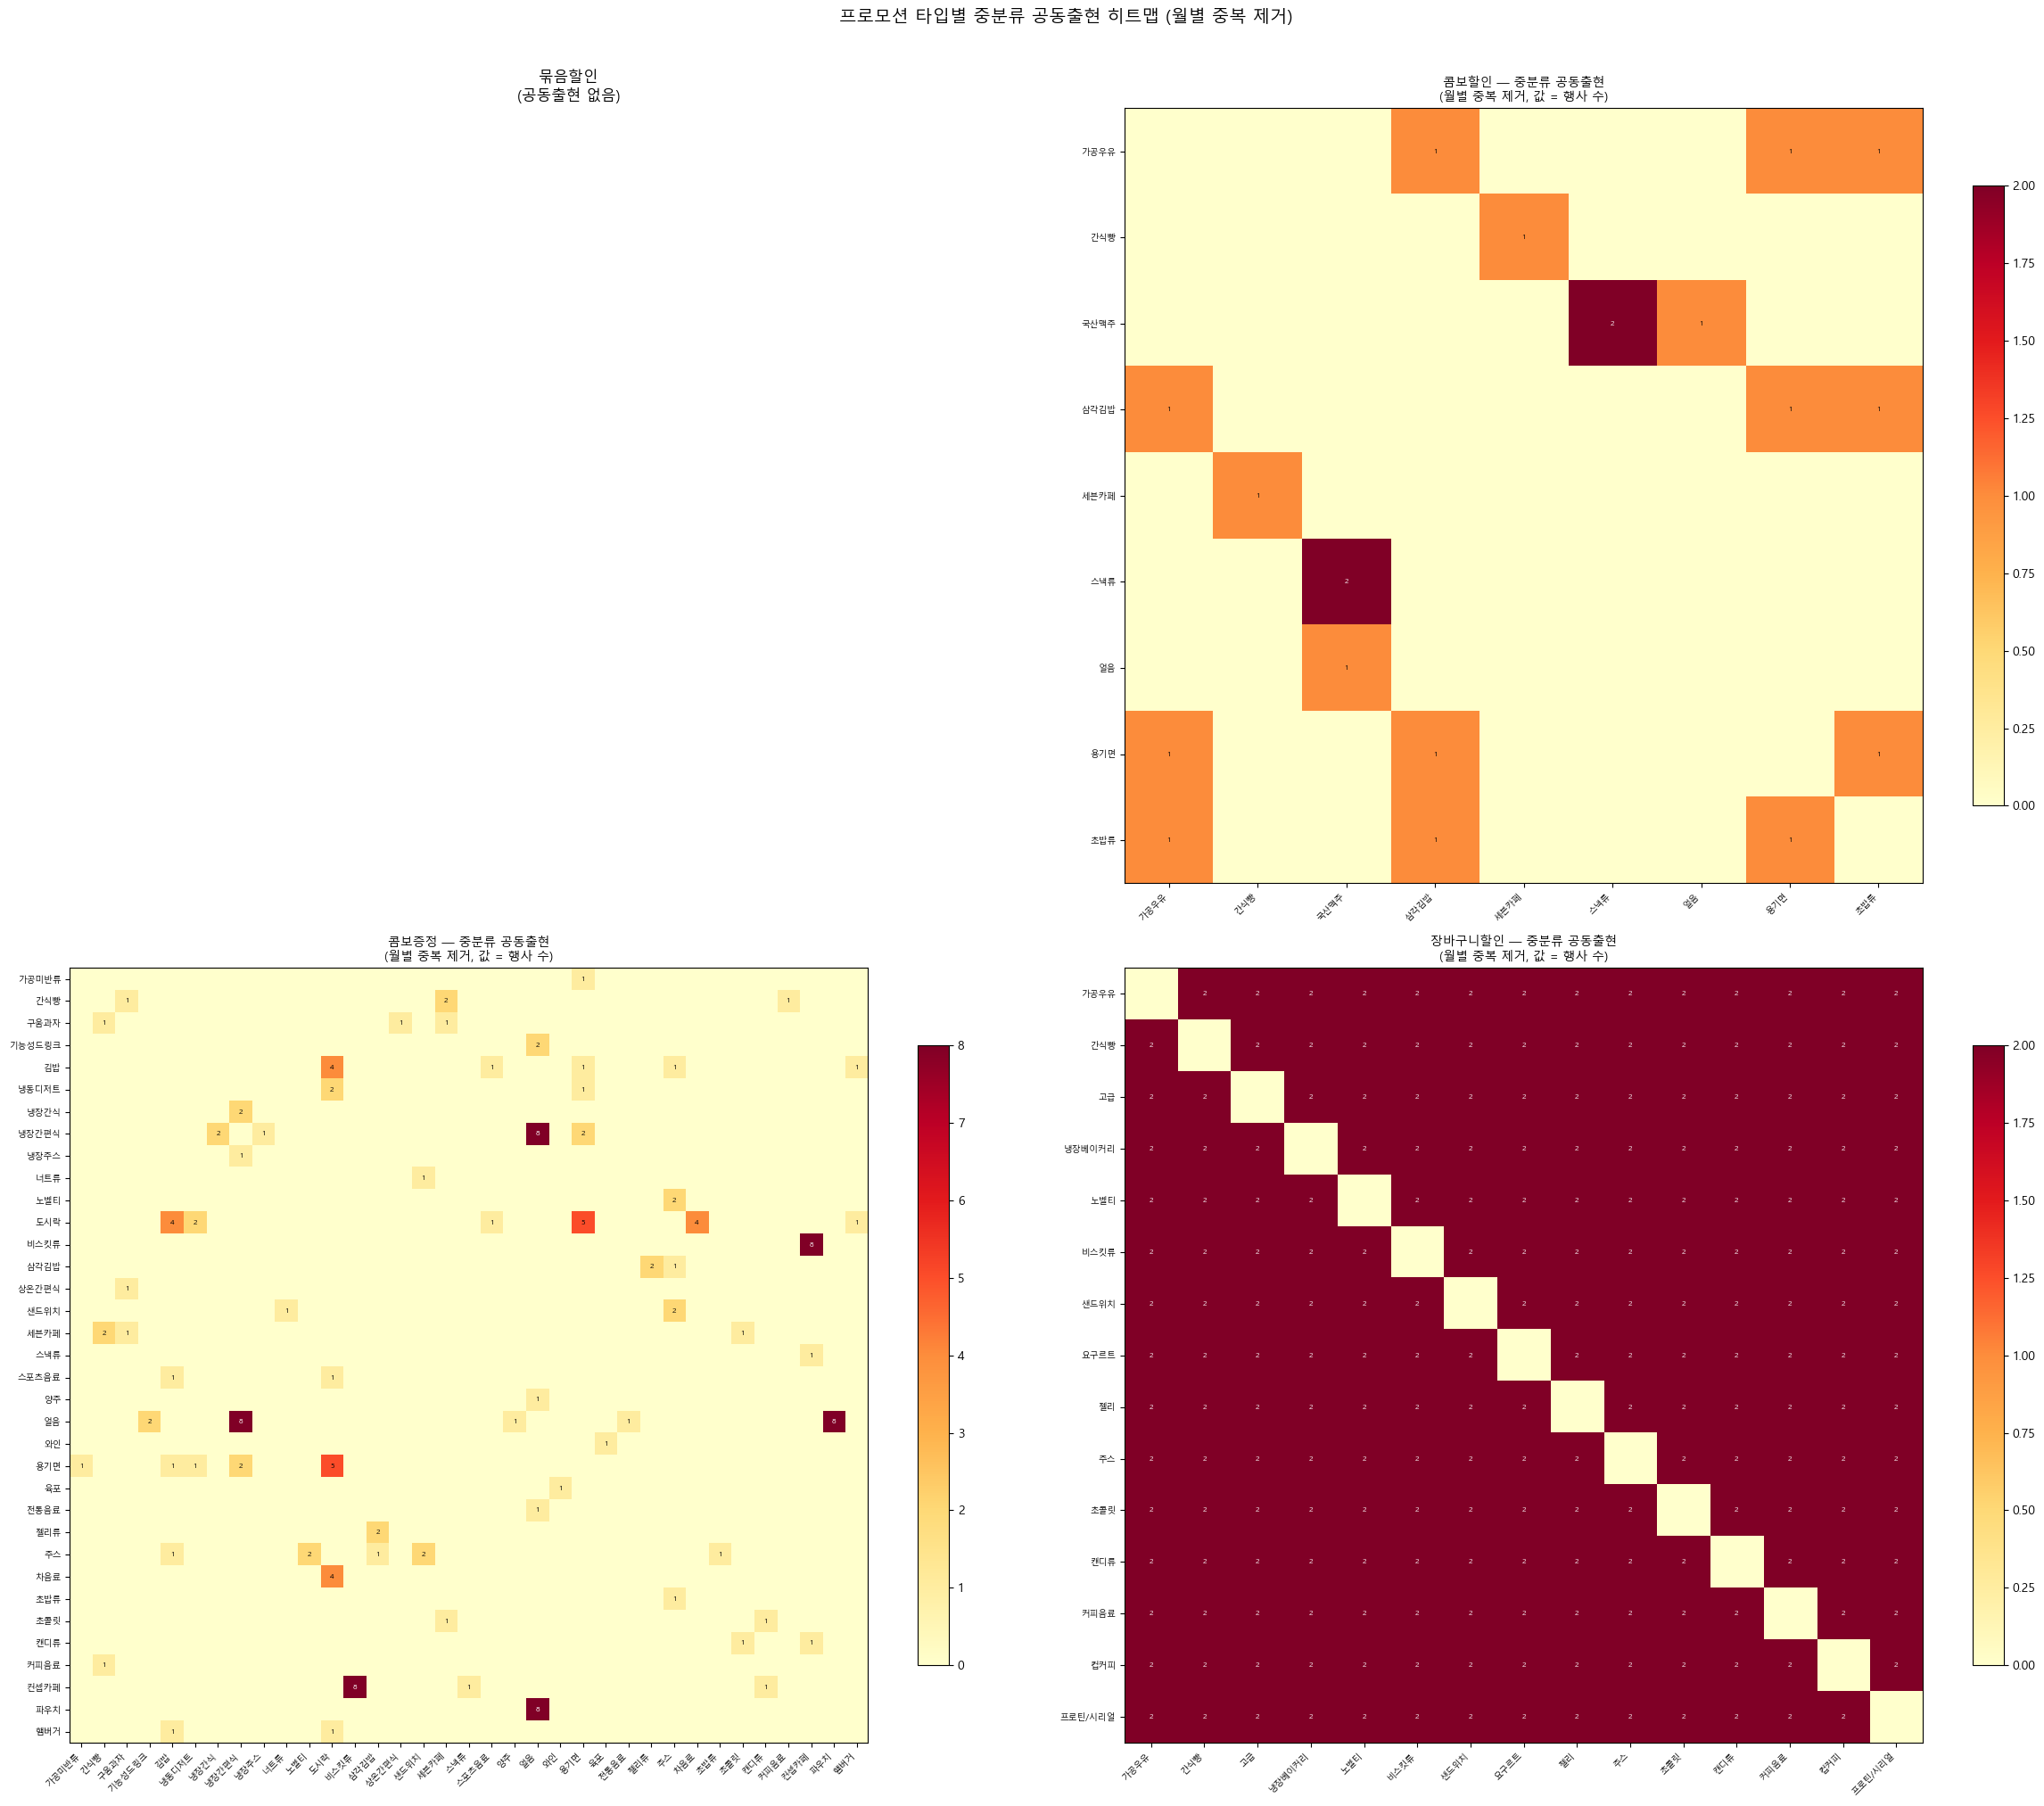

In [30]:
from itertools import combinations
from collections import Counter
import numpy as np

target_types = ['묶음할인', '콤보할인', '콤보증정', '장바구니할인']
fig, axes = plt.subplots(2, 2, figsize=(24, 20))
axes = axes.flatten()

for ax_idx, ptype in enumerate(target_types):
    df_p = df_filtered.filter(pl.col('프로모션_타입') == ptype)
    event_cats_p = (
        df_p
        .group_by('행사명_norm')
        .agg(pl.col('중분류명').drop_nulls().unique().alias('중분류_목록'))
        .filter(pl.col('중분류_목록').list.len() >= 2)
    ).to_pandas()

    pair_counter_p = Counter()
    for cats in event_cats_p['중분류_목록']:
        for pair in combinations(sorted(cats), 2):
            pair_counter_p[pair] += 1

    if not pair_counter_p:
        axes[ax_idx].set_title(f'{ptype}\n(공동출현 없음)')
        axes[ax_idx].axis('off')
        continue

    cats_p = sorted(set(c for pair in pair_counter_p for c in pair))
    n_p = len(cats_p)
    cat_idx_p = {c: i for i, c in enumerate(cats_p)}
    matrix_p = np.zeros((n_p, n_p), dtype=int)
    for (a, b), cnt in pair_counter_p.items():
        i, j = cat_idx_p[a], cat_idx_p[b]
        matrix_p[i, j] = cnt
        matrix_p[j, i] = cnt

    ax = axes[ax_idx]
    im = ax.imshow(matrix_p, cmap='YlOrRd', aspect='auto')
    ax.set_xticks(range(n_p))
    ax.set_yticks(range(n_p))
    ax.set_xticklabels(cats_p, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(cats_p, fontsize=7)
    for i in range(n_p):
        for j in range(n_p):
            if matrix_p[i, j] > 0:
                ax.text(j, i, str(matrix_p[i, j]),
                        ha='center', va='center', fontsize=6,
                        color='black' if matrix_p[i, j] < matrix_p.max() * 0.7 else 'white')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'{ptype} — 중분류 공동출현\n(월별 중복 제거, 값 = 행사 수)', fontsize=10)

plt.suptitle('프로모션 타입별 중분류 공동출현 히트맵 (월별 중복 제거)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


## 8-3. 번들 행사명 Top N 분석 (3+1, 10+1 등)
- 묶음·콤보·증정·장바구니 각 타입별 상위 행사명 직접 확인
- 같은 행사명에 포함된 중분류 구성도 함께 출력
- `행사명_norm` 기준으로 월별 중복 제거 후 집계

In [31]:
target_types = ['묶음할인', '콤보할인', '콤보증정', '장바구니할인']
TOP_N = 10  # 행사명 상위 N개

for ptype in target_types:
    df_p = df_filtered.filter(pl.col('프로모션_타입') == ptype)

    # 행사명별 건수 Top N
    top_events = (
        df_p.group_by('행사명')
        .agg(pl.len().alias('건수'))
        .sort('건수', descending=True)
        .head(TOP_N)
    ).to_pandas()

    # 행사명별 묶인 중분류 목록
    event_cats = (
        df_p.group_by('행사명')
        .agg(pl.col('중분류명').drop_nulls().unique().sort().alias('중분류_목록'))
    ).to_pandas()
    event_cats_dict = dict(zip(event_cats['행사명'], event_cats['중분류_목록']))

    print(f"\n{'='*60}")
    print(f"[{ptype}] 행사명 Top {TOP_N}")
    print(f"{'='*60}")
    for rank, row in top_events.iterrows():
        name = row['행사명']
        cnt  = int(row['건수'])
        cats = event_cats_dict.get(name, [])
        cats_str = ', '.join(cats) if len(cats) > 0 else '(중분류 없음)'
        print(f"  {rank+1:>2}. {name[:30]:<32} ({cnt:>4}건)")
        print(f"      └ 묶인 중분류: {cats_str}")



[묶음할인] 행사명 Top 10

[콤보할인] 행사명 Top 10
   1. 삼각김밥+칠성사이다제로250ml콤보할인행사(12월)     (  80건)
      └ 묶인 중분류: 삼각김밥
   2. 삼각김밥+칠성사이다제로250ml콤보할인행사(10월)     (  79건)
      └ 묶인 중분류: 삼각김밥
   3. 삼각김밥+칠성사이다제로250ml콤보할인행사(8월)      (  78건)
      └ 묶인 중분류: 삼각김밥
   4. 샌드위치+칠성사이다제로250ml콤보할인행사(12월)     (  51건)
      └ 묶인 중분류: 샌드위치
   5. 삼각김밥+칠성사이다제로250ml콤보할인행사(9월)      (  43건)
      └ 묶인 중분류: 삼각김밥
   6. 삼각김밥+칠성사이다제로250ml콤보할인행사(11월)     (  42건)
      └ 묶인 중분류: 삼각김밥
   7. 샌드위치+칠성사이다제로250ml콤보할인행사(1월)      (  35건)
      └ 묶인 중분류: 샌드위치
   8. 도시락+칠성사이다제로250ml콤보할인행사(1월)       (  32건)
      └ 묶인 중분류: 도시락
   9. 도시락+칠성사이다제로250ml콤보할인행사(5월)       (  30건)
      └ 묶인 중분류: 도시락
  10. 김밥+칠성사이다제로250ml콤보할인행사(1월)        (  28건)
      └ 묶인 중분류: 김밥

[콤보증정] 행사명 Top 10
   1. 한일)가쓰오냉소바 구매시, 얼음컵(R) 증정         (  30건)
      └ 묶인 중분류: 냉장간편식, 얼음
   2. 미정)얼음동동냉면2종 구매시, 얼음컵(R) 증정       (  18건)
      └ 묶인 중분류: 냉장간편식, 얼음
   3. 7월 세븐카페 ICE레귤러/라지 만쥬 2종 증정       (  16건)
      └ 묶인 중분류: 간식빵, 세븐카페
   4. 한일)초계국수 구매시, 얼음컵(R) 증정           (  15건)
 

## 9. 카테고리 내 프로모션 집중도 분석

### 분석 목적
카테고리(중분류) 내에서 행사가 소수 상품에 몰려 있는지, 아니면 고르게 분산되어 있는지를 측정한다.
이 결과는 HIN에서 **[중분류] — [프로모션_타입] 엣지의 가중치**를 결정하는 근거로 활용된다.

### 지표 정의

| 지표 | 정의 | 해석 |
|------|------|------|
| **커버리지 (%)** | B4 전체 상품 중 B5 행사 참여 상품 비율 | 높을수록 카테고리 전반이 행사 대상 |
| **Gini 계수** | 상품별 행사 횟수의 불평등도 (0=완전균등, 1=완전독점) | 전체 분포의 집중 정도를 반영 |
| **파레토 상위 20% (%)** | 상위 20% 상품이 전체 행사 횟수에서 차지하는 비율 | 극단적 소수 독점 여부에 초점 |

**Gini vs 파레토 차이**: Gini는 중간층 분포까지 반영해 분포 전체의 불평등을 측정하고, 파레토는 상위 20%라는 고정 기준선 기반으로 극단 집중 여부만 판단한다. 같은 카테고리라도 두 값이 다를 수 있다.

### HIN 엣지 가중치 설계 (집중도 분석 기반)

#### [상품] — [프로모션_타입] 엣지
```
w = 해당 상품의 해당 프로모션 타입 행사 횟수  (product_freq에서 직접 추출)
```
상품 단위 행사 빈도가 연결 강도를 직접 표현한다.

#### [중분류] — [프로모션_타입] 엣지
```
w = (해당 조합 참여 상품수 / 중분류 총 참여 상품수) × (1 - Gini)
```
- **상품수 비율**: 이 카테고리에서 해당 프로모션이 얼마나 넓게 쓰이는지 (대표성)
- **× (1 - Gini)**: Gini가 높은 카테고리는 소수 상품이 엣지를 대표하는 구조이므로 가중치를 낮춰 신뢰도 보정

#### [상품] — [중분류] 엣지
```
w = 1.0  (B4 기준 1:1 고정 매핑)
```

### 구조 해석 기준

| 조건 | 네트워크 구조 | 시사점 |
|------|-------------|--------|
| Gini > 0.5 & 파레토 > 80% | 허브 구조 | 소수 핵심 상품이 행사를 독점, 엣지 가중치 차별화 효과 큼 |
| Gini < 0.3 & 파레토 < 60% | 분산 구조 | 카테고리 전반에 행사 분포, 중분류 노드가 실질적 대표성 가짐 |

=== 카테고리별 프로모션 집중도 (Gini 내림차순) ===
   중분류명  B4_전체상품  행사참여상품  커버리지(%)  Gini  파레토상위20%(%)  상품당평균행사  최대행사횟수
     얼음      107      15     14.0 0.597         64.3      8.6      28
     양주     1038      81      7.8 0.532         56.8     15.0      73
     와인     2088     251     12.0 0.500         54.8     29.1     146
    도시락     2375     120      5.1 0.498         53.4     10.7      67
     젤리      302      42     13.9 0.496         51.9      4.4      15
    용기면      845     151     17.9 0.479         50.7      5.6      20
    흰우유      203      15      7.4 0.477         52.1      4.7      13
   비스킷류     6335     229      3.6 0.475         52.2      3.7      15
   구움과자      533      29      5.4 0.471         47.0      4.0      14
  기타전통주      505      48      9.5 0.471         52.5      6.8      30
   건해산물      666       6      0.9 0.448         37.5      5.3      12
     주스     1039      79      7.6 0.446         43.1      6.9      18
 냉장베이커리      899      15      1.7 0.444         44.4   

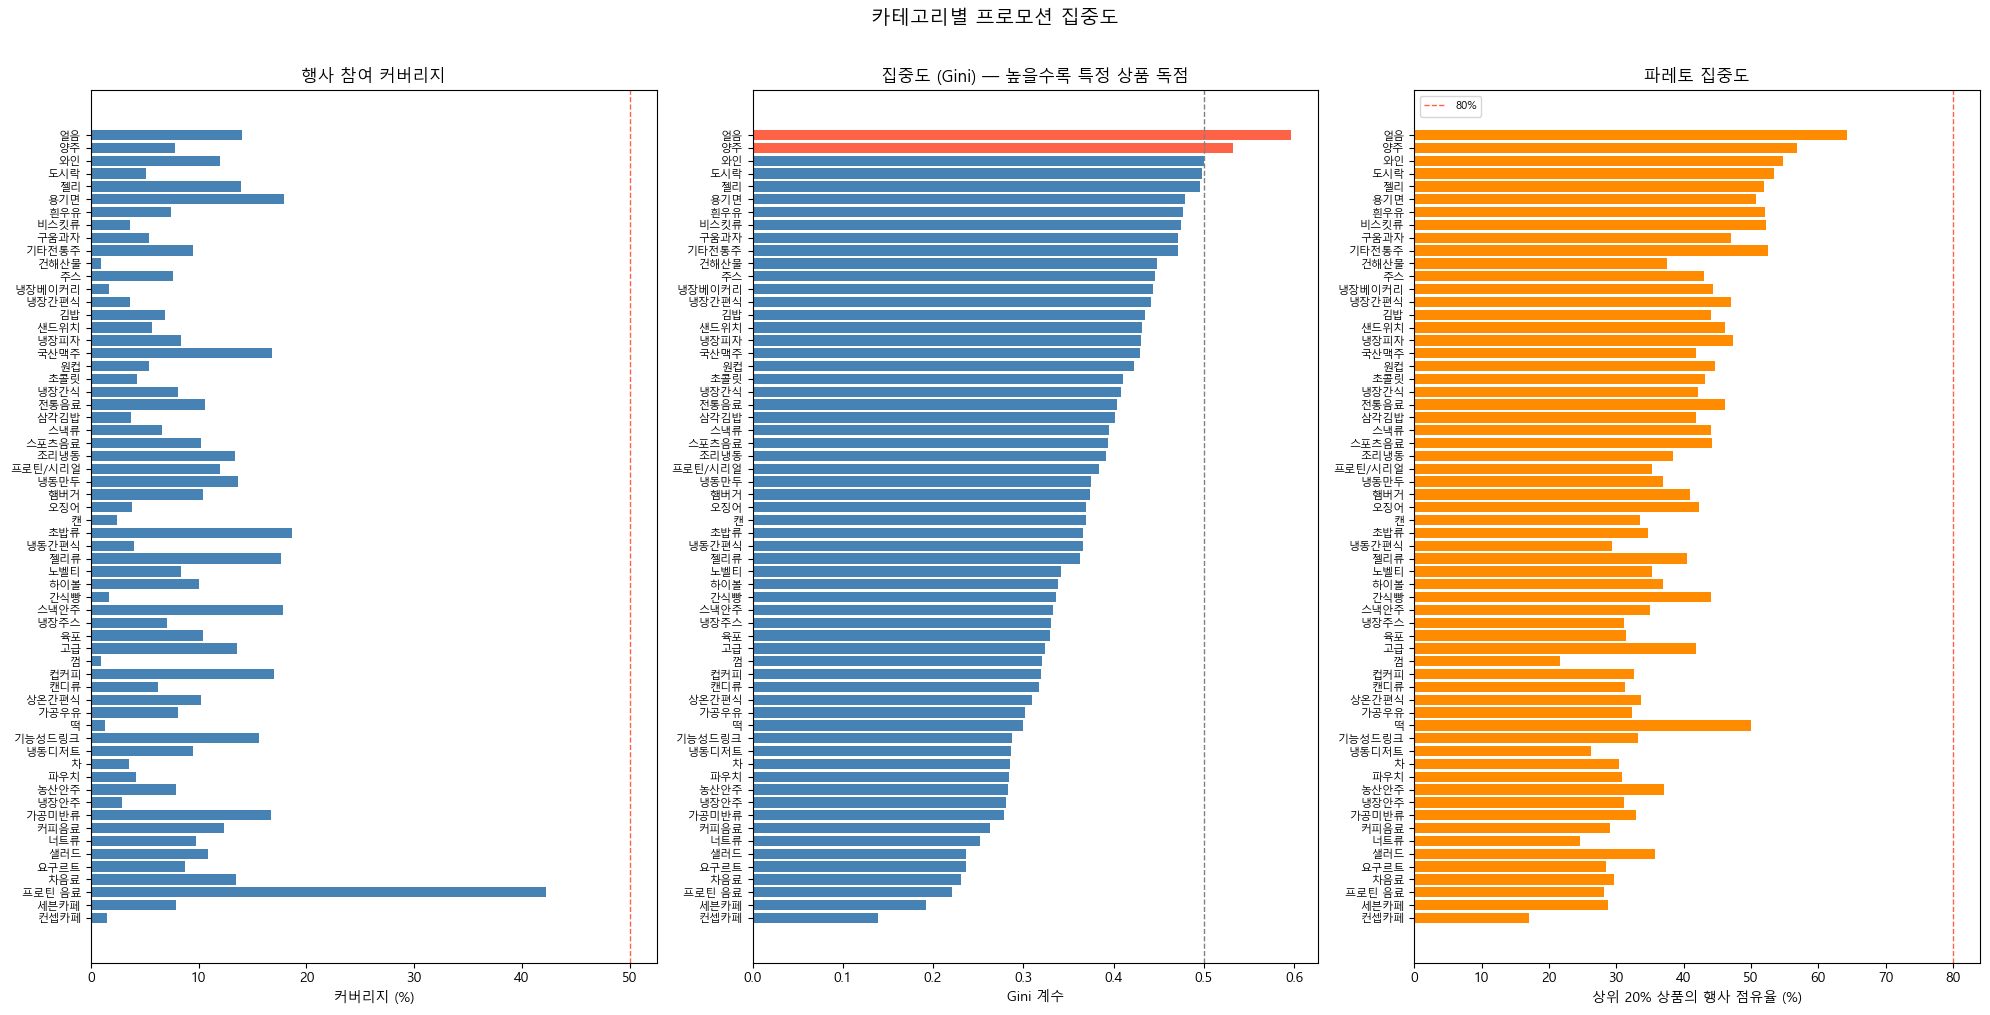

=== 카테고리별 프로모션 유형 전체 현황 ===
[얼음]  참여상품=15개  Gini=0.597
  콤보증정          상품: 12개  건수: 125  ████████████████████
  1+1           상품:  2개  건수:   3  
  콤보할인          상품:  1개  건수:   1  
[양주]  참여상품=81개  Gini=0.532
  번들할인          상품: 48개  건수: 946  ████████████████████
  단품할인          상품: 53개  건수: 216  ████
  구독행사          상품: 21개  건수:  53  █
  콤보증정          상품:  3개  건수:   3  
[와인]  참여상품=251개  Gini=0.5
  번들할인          상품:205개  건수:6496  ████████████████████
  단품할인          상품:110개  건수: 634  █
  구독행사          상품: 93개  건수: 175  
  콤보증정          상품:  2개  건수:   2  
  장바구니할인        상품:  1개  건수:   1  
[도시락]  참여상품=120개  Gini=0.498
  구독행사          상품:112개  건수: 786  ████████████████████
  콤보할인          상품: 71개  건수: 303  ███████
  번들할인          상품: 17개  건수: 142  ███
  콤보증정          상품: 19개  건수:  48  █
  단품할인          상품:  1개  건수:   1  
[젤리]  참여상품=42개  Gini=0.496
  2+1           상품: 39개  건수: 106  ████████████████████
  1+1           상품: 10개  건수:  40  ███████
  장바구니할인        상품:  2개  건수:  16  ███
  번들할인   

In [32]:
import numpy as np

# B4 전체 상품 수 (카테고리별 모수)
b4_cat_total = (
    df_b4.group_by('중분류명')
    .agg(pl.col('상품코드').n_unique().alias('b4_전체상품수'))
)

# B5 filtered: 상품별 행사 횟수 집계
product_freq = (
    df_filtered
    .group_by(['중분류명', '상품코드'])
    .agg(pl.len().alias('행사횟수'))
)

def gini(arr):
    arr = np.sort(np.array(arr, dtype=float))
    n = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    idx = np.arange(1, n + 1)
    return (2 * (idx * arr).sum()) / (n * arr.sum()) - (n + 1) / n

def pareto_ratio(arr):
    arr = np.sort(np.array(arr, dtype=float))[::-1]
    n = len(arr)
    if n == 0: return 0.0
    top_n = max(1, int(n * 0.2))
    return arr[:top_n].sum() / arr.sum() * 100

# 카테고리별 집중도 지표
rows = []
for cat, grp in product_freq.to_pandas().groupby('중분류명'):
    freq = grp['행사횟수'].values
    b4_n = b4_cat_total.filter(pl.col('중분류명') == cat)['b4_전체상품수']
    b4_n = b4_n[0] if len(b4_n) > 0 else len(freq)
    rows.append({
        '중분류명':        cat,
        'B4_전체상품':     int(b4_n),
        '행사참여상품':    len(freq),
        '커버리지(%)':     round(len(freq) / b4_n * 100, 1),
        'Gini':            round(gini(freq), 3),
        '파레토상위20%(%)': round(pareto_ratio(freq), 1),
        '상품당평균행사':  round(freq.mean(), 1),
        '최대행사횟수':    int(freq.max()),
    })

df_conc = pd.DataFrame(rows).sort_values('Gini', ascending=False).reset_index(drop=True)

print("=== 카테고리별 프로모션 집중도 (Gini 내림차순) ===")
print(df_conc.to_string(index=False))

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

cats = df_conc['중분류명']
y = range(len(cats))

# 좌: 커버리지
axes[0].barh(y, df_conc['커버리지(%)'], color='steelblue')
axes[0].set_yticks(y); axes[0].set_yticklabels(cats, fontsize=8)
axes[0].set_xlabel('커버리지 (%)'); axes[0].set_title('행사 참여 커버리지')
axes[0].axvline(50, color='tomato', linestyle='--', linewidth=1)
axes[0].invert_yaxis()

# 중: Gini
colors = ['tomato' if g > 0.5 else 'steelblue' for g in df_conc['Gini']]
axes[1].barh(y, df_conc['Gini'], color=colors)
axes[1].set_yticks(y); axes[1].set_yticklabels(cats, fontsize=8)
axes[1].set_xlabel('Gini 계수'); axes[1].set_title('집중도 (Gini) — 높을수록 특정 상품 독점')
axes[1].axvline(0.5, color='gray', linestyle='--', linewidth=1)
axes[1].invert_yaxis()

# 우: 파레토
axes[2].barh(y, df_conc['파레토상위20%(%)'], color='darkorange')
axes[2].set_yticks(y); axes[2].set_yticklabels(cats, fontsize=8)
axes[2].set_xlabel('상위 20% 상품의 행사 점유율 (%)'); axes[2].set_title('파레토 집중도')
axes[2].axvline(80, color='tomato', linestyle='--', linewidth=1, label='80%')
axes[2].legend(fontsize=8)
axes[2].invert_yaxis()

plt.suptitle('카테고리별 프로모션 집중도', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 카테고리 × 프로모션 타입 전체 출력
print("" + "="*70)
print("=== 카테고리별 프로모션 유형 전체 현황 ===")
print("="*70)

cat_promo = (
    df_filtered
    .group_by(['중분류명', '프로모션_타입'])
    .agg([
        pl.col('상품코드').n_unique().alias('상품수'),
        pl.len().alias('행사건수'),
    ])
    .sort(['중분류명', '행사건수'], descending=[False, True])
    .to_pandas()
)

for cat in df_conc['중분류명']:
    sub = cat_promo[cat_promo['중분류명'] == cat]
    total_prod = df_conc.loc[df_conc['중분류명']==cat, '행사참여상품'].values[0]
    gini_val   = df_conc.loc[df_conc['중분류명']==cat, 'Gini'].values[0]
    print(f"[{cat}]  참여상품={total_prod}개  Gini={gini_val}")
    for _, r in sub.iterrows():
        bar = '█' * min(int(r['행사건수'] / sub['행사건수'].max() * 20), 20)
        print(f"  {r['프로모션_타입']:12s}  상품:{r['상품수']:3d}개  건수:{r['행사건수']:4d}  {bar}")


## 10. 시기 노드 후보 발굴 — 행사명 기반 분류
행사명 텍스트에서 기념일/계절/정기행사 키워드를 추출해 시기 후보를 정의한다.

In [33]:
# 행사명 전수 출력 (건수 많은 순) — 시기 키워드 귀납 정의용
행사명_vc = (
    df.group_by('행사명')
    .agg(pl.len().alias('건수'))
    .sort('건수', descending=True)
    .to_pandas()
)
print(f"행사명 고유값: {len(행사명_vc)}개\n")
print(행사명_vc.to_string(index=False))

행사명 고유값: 8390개

                                                    행사명   건수
                             아이스크림 3개 2+1, 5개 50% 할인 행사 1008
                                        토이캔디 균일가 1천원 행사  674
                                 202507 세븐카페 구독행사(700원)  495
                                              아이스크림 1+1  405
                                              아이스크림 2+1  326
                                       202507 세븐카페 구독행사  308
                                       202505 세븐카페 구독행사  249
                                       202501 세븐카페 구독행사  248
                                     아이스크림 3개 34% 할인 행사  235
                      07월 음료 1+1 브랜드, 가격 상관없이 교차 할인 행사   204
                         음료 1+1 가격 브랜드, 상관없이 교차 할인행사     204
                        07월 음료 상품, 브랜드, 가격 상관없이 1+1 행사   202
                         07월 음료 1+1 가격, 브랜드 상광없이 교차 행사   202
                             음료 가격, 브랜드 상관없이 1+1 교차 행사   201
                           캐시비 교통카드 할인행사(연예인,귀멸의칼날,리니지)  196
        

In [34]:
import json
from collections import Counter

SEVEN_PATH = os.path.join(BASE, 'data', 'processed', 'instagram_7elevenkorea_2025-01-01_to_2025-12-31.csv')
df_7 = pd.read_csv(SEVEN_PATH, encoding='utf-8-sig')

kw_col = 'hin_pipeline_json'
print(f"전체 게시물: {len(df_7)}건 / 키워드 추출 완료: {df_7[kw_col].notna().sum()}건\n")

tpo_counter    = Counter()
flavor_counter = Counter()
collab_counter = Counter()
promo_counter  = Counter()

for raw in df_7[kw_col].dropna():
    try:
        parsed = json.loads(raw)
    except Exception:
        continue
    for m in parsed.get('metadata', []):
        for v in (m.get('tpo_context') or []):
            if isinstance(v, str):
                tpo_counter[v.strip()] += 1
        for v in (m.get('flavor_and_category') or []):
            if isinstance(v, str):
                flavor_counter[v.strip()] += 1
        for v in (m.get('collab_and_brand') or []):
            if isinstance(v, str):
                collab_counter[v.strip()] += 1
        pt = m.get('promotion_type')
        if isinstance(pt, list):
            for v in pt:
                if isinstance(v, str):
                    promo_counter[v.strip()] += 1
        elif isinstance(pt, str):
            promo_counter[pt.strip()] += 1

def print_counter(title, counter, n=50):
    print(f"=== {title} (상위 {n}개) ===")
    for val, cnt in counter.most_common(n):
        print(f"  {cnt:4d}  {val}")
    print()

print_counter("tpo_context (시기/상황 힌트)", tpo_counter)
print_counter("flavor_and_category", flavor_counter)
print_counter("promotion_type", promo_counter)
print_counter("collab_and_brand", collab_counter, n=30)

전체 게시물: 813건 / 키워드 추출 완료: 813건

=== tpo_context (시기/상황 힌트) (상위 50개) ===
   171  간식
   107  야식
    85  간편식
    64  식사
    64  디저트
    63  선물
    47  발렌타인데이
    41  화이트데이
    39  여름
    36  응원
    34  시즌한정
    34  점심
    27  크리스마스
    19  연말
    18  명절
    18  직관
    18  저당
    16  식사대용
    15  건강한
    13  저녁
    12  봄맛 페스티벌
    11  가을
    10  집캉스
    10  여행
    10  야구
    10  스포츠
    10  안주
     9  건강
     9  한끼
     8  음료
     8  주류
     8  한 끼 식사
     7  신상
     7  다이어트
     7  파티
     7  휴가
     7  직관 전
     7  경기장
     7  가성비
     6  일상생활
     6  경기관람
     6  팬심
     6  슬로에이징
     6  한끼식사
     6  스포츠 관람
     6  건강식
     6  독서실
     6  공부할 때
     6  출출할 때
     6  패션

=== flavor_and_category (상위 50개) ===
    73  도시락
    64  디저트
    62  딸기
    58  삼각김밥
    57  초코
    49  김밥
    47  스낵
    38  샌드
    32  빵
    30  라면
    29  말차
    29  굿즈
    28  케이크
    27  음료
    27  커피
    26  매콤
    26  매운맛
    25  크림
    24  망고
    24  버거
    23  불고기
    23  레몬
    22  파스타
    22  비빔밥
    22  우유
  

In [35]:
# B5 행사명 기반 시기 분류 + 월별 행사 추출

행사명_vc = (
    df.group_by('행사명')
    .agg(pl.len().alias('건수'))
    .sort('건수', descending=True)
    .to_pandas()
)

# ── 1. 시기 키워드 분류 ──────────────────────────────────────────
SIGI_KEYWORDS = [
    ("설날",         ["설날", "구정", "설맞이", "새해", "신정", "정월", "복주머니", "세뱃돈", "복(福)", "설 특"]),
    ("발렌타인데이", ["발렌타인"]),
    ("화이트데이",   ["화이트데이"]),
    ("봄페스티벌",   ["봄맛", "봄 페스티벌", "봄페스티벌", "봄 시즌", "봄 행사", "봄특가",
                      "벚꽃", "spring", "스프링", "나들이", "소풍", "피크닉", "신학기"]),
    ("야구/스포츠",  ["야구", "k리그", "kbo", "직관", "스포츠", "응원"]),
    ("여름/휴가",    ["여름", "썸머", "summer", "휴가", "바캉스", "집캉스",
                      "빙과", "아이스크림", "빙수", "시원한", "쿨(cool)", "냉장", "냉면"]),
    ("추석",         ["추석", "한가위", "명절"]),
    ("가을",         ["가을", "단풍", "추수", "harvest", "수확", "가을맞이", "가을 시즌", "가을특가"]),
    ("핼러윈",       ["핼러윈", "할로윈", "halloween", "호박", "귀신", "유령", "공포", "마녀", "halloween"]),
    ("빼빼로데이",   ["빼빼로"]),
    ("크리스마스",   ["크리스마스", "christmas", "xmas"]),
    ("연말",         ["연말", "송년", "겨울", "winter", "윈터", "year end", "연말연시"]),
]

def classify_sigi(name: str) -> str:
    n = name.lower()
    for sigi, kws in SIGI_KEYWORDS:
        if any(kw.lower() in n for kw in kws):
            return sigi
    return None

행사명_vc["시기"] = 행사명_vc["행사명"].apply(classify_sigi)
sigi_df = 행사명_vc[행사명_vc["시기"].notna()].copy()

print("=== 시기 분류된 행사명 (B5) ===\n")
for sigi, _ in SIGI_KEYWORDS:
    sub = sigi_df[sigi_df["시기"] == sigi].sort_values("건수", ascending=False)
    if sub.empty:
        print(f"[{sigi}]  → 해당 없음")
        continue
    print(f"[{sigi}]  {len(sub)}종 / 총 {sub['건수'].sum():,}건")
    for _, r in sub.iterrows():
        print(f"    {r['건수']:5d}건  {r['행사명']}")
    print()

print(f"시기 분류 합계: {len(sigi_df)}종 / {sigi_df['건수'].sum():,}건")
print(f"미분류(일반):   {len(행사명_vc) - len(sigi_df)}종 / {(행사명_vc['건수'].sum() - sigi_df['건수'].sum()):,}건")

# ── 2. 특정 월(1월~12월)이 포함된 행사명 추출 ──────────────────
print("\n\n" + "="*60)
print("=== 월(月) 표기 포함 행사명 ===\n")

import re
month_pattern = re.compile(r'(?<!\d)([1-9]|1[0-2])월')

행사명_vc["포함월"] = 행사명_vc["행사명"].apply(
    lambda x: [int(m) for m in month_pattern.findall(x)] or None
)
month_df = 행사명_vc[행사명_vc["포함월"].notna()].copy()

for month in range(1, 13):
    sub = month_df[month_df["포함월"].apply(lambda ms: month in ms)].sort_values("건수", ascending=False)
    if sub.empty:
        continue
    print(f"[{month}월]  {len(sub)}종 / 총 {sub['건수'].sum():,}건")
    for _, r in sub.head(10).iterrows():
        print(f"    {r['건수']:5d}건  {r['행사명']}")
    if len(sub) > 10:
        print(f"    ... 외 {len(sub)-10}종")
    print()

=== 시기 분류된 행사명 (B5) ===

[설날]  → 해당 없음
[발렌타인데이]  7종 / 총 64건
       20건  25년 2월 발렌타인추가 bc페이북
       20건  25년 2월 발렌타인 추가 bc카드
       20건  25년 2월 발렌타인 추가 우리bc
        1건  25년 2월 발렌타인 추가_bc페이북
        1건  25년 2월 발렌타인 추가_우리bc
        1건  코리아)발렌타인플래티넘콘돔5입_H 2+1
        1건  2월 발렌타인 추가행사 (abc초콜릿)

[화이트데이]  2종 / 총 43건
       34건  3월 화이트데이 기획상품 33종 카카오페이 20% 할인
        9건  3월 화이트데이 로쉐 9종 농협카드 20% 할인

[봄페스티벌]  6종 / 총 30건
       20건  신학기 문구류 이즐카드로 결제시 50% 할인 행사
        4건  25년 11월 티처스)A4스프링노트 외 3종 2+1
        2건  농심)츄파춥스벚꽃에디션100틴  2+1
        2건  드림)훈와리메이진벚꽃모찌26g 2+1
        1건  드림)훈와리메이진벚꽃모찌 2+1행사(10.01~10.31)
        1건  드림)훈와리메이진벚꽃모찌26g 2+1행사

[야구/스포츠]  42종 / 총 369건
       45건  K리그산리오 문구완구 50%행사(3)
       39건  K리그산리오 문구완구 50%행사(2)
       29건  K리그산리오 문구완구 50%행사(4)
       29건  K리그산리오 문구완구 50%행사(1)
       25건  k리그 산리오 반값행사(패션잡화)
       25건  K리그산리오 일용잡화 50% 할인
       15건  K리그산리오 굿즈 추가 행사(메탈뱃지 15종)
       15건  K리그산리오 굿즈 추가 행사(아크릴볼펜15종)
       15건  K리그산리오 굿즈 추가 행사(투명슬림파우치 15종)
       15건  K리그산리오 굿즈 추

## 11. 인스타 행사 게시물 × B5 프로모션 매칭
**흐름**: 행사 관련 Instagram 게시물 필터링 → 상품명 추출 → B5와 날짜(C) + 키워드(A) 매칭 → 인스타 키워드 + 행사명 나란히 확인

In [36]:
import json, re
import pandas as pd

SEVEN_PATH = os.path.join(BASE, 'data', 'processed', 'instagram_7elevenkorea_2025-01-01_to_2025-12-31.csv')
df_7 = pd.read_csv(SEVEN_PATH, encoding='utf-8-sig')

# ── Step 1. 행사 관련 게시물 필터링 ────────────────────────────
행사_kws = ['1+1', '2+1', '3+1', '행사', '이벤트', '할인', '한정', '증정', '출시', '신상', '특가']

def is_promo_post(row):
    try:
        parsed = json.loads(row['hin_pipeline_json'])
        for m in parsed.get('metadata', []):
            pt = m.get('promotion_type', '')
            if isinstance(pt, list) and any(str(v).strip() for v in pt if v):
                return True
            elif isinstance(pt, str) and pt.strip():
                return True
    except Exception:
        pass
    text = str(row.get('title', '')) + str(row.get('body', ''))
    return any(kw in text for kw in 행사_kws)

df_7['is_promo'] = df_7.apply(is_promo_post, axis=1)
promo_posts = df_7[df_7['is_promo']].copy()
print(f"전체 게시물: {len(df_7)}건 → 행사 관련: {len(promo_posts)}건\n")

# ── Step 2. 인스타 상품 레코드 추출 ────────────────────────────
def safe_join(lst):
    """None 제거 후 join"""
    return ', '.join(str(v) for v in (lst or []) if v is not None)

records = []
for _, row in promo_posts.iterrows():
    try:
        parsed = json.loads(row['hin_pipeline_json'])
    except Exception:
        continue
    try:
        post_date = pd.to_datetime(row['date']).date()
    except Exception:
        continue
    for m in parsed.get('metadata', []):
        name = (m.get('name') or '').strip()
        if not name:
            continue
        pt = m.get('promotion_type', '')
        if isinstance(pt, list):
            pt = ', '.join(str(v) for v in pt if v)
        records.append({
            'post_id':             row['post_id'],
            'post_date':           post_date,
            'insta_product':       name,
            'tpo_context':         safe_join(m.get('tpo_context')),
            'flavor_and_category': safe_join(m.get('flavor_and_category')),
            'insta_promo_type':    str(pt).strip(),
            'collab_and_brand':    safe_join(m.get('collab_and_brand')),
        })

df_inst = pd.DataFrame(records)
print(f"인스타 상품 레코드: {len(df_inst)}건 / 고유 상품명: {df_inst['insta_product'].nunique()}개\n")

# ── Step 3. B5 pandas 변환 (포함 카테고리 기준) ────────────────
df_b5 = df_filtered.to_pandas()
df_b5['개시일'] = pd.to_datetime(df_b5['행사개시일']).dt.date

def safe_end_date(ts):
    try:
        d = pd.to_datetime(ts).date()
        return d if d.year < 9000 else pd.Timestamp('2099-12-31').date()
    except Exception:
        return pd.Timestamp('2099-12-31').date()

df_b5['종료일'] = df_b5['행사종료일'].apply(safe_end_date)

# ── Step 4. A+C 매칭 ───────────────────────────────────────────
def tokenize(name: str):
    tokens = re.sub(r'[^\w가-힣a-zA-Z0-9]', ' ', name).split()
    return [t for t in tokens if len(t) >= 2]

def match_score(insta_name: str, b5_name: str) -> int:
    tokens = tokenize(insta_name)
    b5_lower = b5_name.lower()
    return sum(1 for t in tokens if t.lower() in b5_lower)

match_results = []
for _, inst in df_inst.iterrows():
    post_date = inst['post_date']
    insta_name = inst['insta_product']
    if not tokenize(insta_name):
        continue

    # C: 날짜 범위로 후보 축소
    cand = df_b5[(df_b5['개시일'] <= post_date) & (df_b5['종료일'] >= post_date)].copy()
    if cand.empty:
        continue

    # A: 키워드 매칭
    cand['score'] = cand['상품명'].apply(lambda x: match_score(insta_name, str(x)))
    cand = cand[cand['score'] > 0].sort_values('score', ascending=False)
    if cand.empty:
        continue

    best = cand.iloc[0]
    match_results.append({
        'post_date':           post_date,
        'insta_product':       insta_name,
        'tpo_context':         inst['tpo_context'],
        'flavor_and_category': inst['flavor_and_category'],
        'insta_promo_type':    inst['insta_promo_type'],
        'collab_and_brand':    inst['collab_and_brand'],
        'b5_상품명':           best['상품명'],
        'b5_행사명':           best['행사명'],
        'b5_프로모션_타입':    best['프로모션_타입'],
        'b5_행사기간':         f"{best['개시일']} ~ {best['종료일']}",
        'match_score':         int(best['score']),
    })

df_matched = pd.DataFrame(match_results).sort_values(['post_date', 'match_score'], ascending=[True, False])
print(f"매칭 성공: {len(df_matched)}건 / 미매칭: {len(df_inst) - len(df_matched)}건\n")

# ── Step 5. 결과 출력 ──────────────────────────────────────────
print("=== 인스타 키워드 × B5 행사명 매칭 결과 (score 높은 순) ===\n")
for _, r in df_matched.sort_values('match_score', ascending=False).head(50).iterrows():
    print(f"[{r['post_date']}] {r['insta_product']}  →  {r['b5_상품명']}")
    print(f"  tpo        : {r['tpo_context']}")
    print(f"  flavor     : {r['flavor_and_category']}")
    print(f"  insta_promo: {r['insta_promo_type']}")
    print(f"  collab     : {r['collab_and_brand']}")
    print(f"  B5 행사명  : {r['b5_행사명']}  [{r['b5_프로모션_타입']}]  {r['b5_행사기간']}")
    print(f"  score      : {r['match_score']}")
    print()

전체 게시물: 813건 → 행사 관련: 702건

인스타 상품 레코드: 1519건 / 고유 상품명: 1024개

매칭 성공: 976건 / 미매칭: 543건

=== 인스타 키워드 × B5 행사명 매칭 결과 (score 높은 순) ===

[2025-01-22] 오뚜기 참깨라면 소컵 6입 박스  →  오뚜기)참깨라면소컵6입박스
  tpo        : 
  flavor     : 참깨, 라면
  insta_promo: 1+1
  collab     : 오뚜기
  B5 행사명  : 오뚜기)참깨라면소컵6입박스 1+1  [1+1]  2025-01-15 ~ 2025-01-31
  score      : 5

[2025-11-26] 아모스 4D 베리 믹스 구미  →  G)아모스4D베리믹스구미56g
  tpo        : 간식
  flavor     : 베리, 젤리
  insta_promo: 2+1
  collab     : 레고
  B5 행사명  : G)아모스4D젤리 2종 11월 2+1  [2+1]  2025-11-26 ~ 2025-11-30
  score      : 5

[2025-12-30] 적토마토 베이컨 듬뿍 토스트 샌드  →  적토마토)베이컨듬뿍토스트샌드
  tpo        : 간편식
  flavor     : 토스트샌드
  insta_promo: 
  collab     : 적토마토
  B5 행사명  : 샌드위치+칠성사이다제로250ml콤보할인행사(12월)  [콤보할인]  2025-12-30 ~ 2025-12-31
  score      : 5

[2025-11-26] 아모스 4D 드레스업 구미  →  G)아모스4D드레스업구미56g
  tpo        : 간식
  flavor     : 상큼달콤, 젤리
  insta_promo: 2+1
  collab     : 레고
  B5 행사명  : G)아모스4D젤리 2종 11월 2+1  [2+1]  2025-11-26 ~ 2025-11-30
  score      : 4

[2025-09-23] 콕콕콕 더커

In [37]:
# 행사 필터 없이 전체 813건 기준 매칭 비교

records_all = []
for _, row in df_7.iterrows():
    try:
        parsed = json.loads(row['hin_pipeline_json'])
    except Exception:
        continue
    try:
        post_date = pd.to_datetime(row['date']).date()
    except Exception:
        continue
    for m in parsed.get('metadata', []):
        name = (m.get('name') or '').strip()
        if not name:
            continue
        pt = m.get('promotion_type', '')
        if isinstance(pt, list):
            pt = ', '.join(str(v) for v in pt if v)
        records_all.append({
            'post_id':             row['post_id'],
            'post_date':           post_date,
            'insta_product':       name,
            'tpo_context':         safe_join(m.get('tpo_context')),
            'flavor_and_category': safe_join(m.get('flavor_and_category')),
            'insta_promo_type':    str(pt).strip(),
            'collab_and_brand':    safe_join(m.get('collab_and_brand')),
        })

df_inst_all = pd.DataFrame(records_all)
print(f"전체 게시물 기준 상품 레코드: {len(df_inst_all)}건 / 고유 상품명: {df_inst_all['insta_product'].nunique()}개")

# 매칭
match_all = []
for _, inst in df_inst_all.iterrows():
    post_date = inst['post_date']
    insta_name = inst['insta_product']
    if not tokenize(insta_name):
        continue
    cand = df_b5[(df_b5['개시일'] <= post_date) & (df_b5['종료일'] >= post_date)].copy()
    if cand.empty:
        continue
    cand['score'] = cand['상품명'].apply(lambda x: match_score(insta_name, str(x)))
    cand = cand[cand['score'] > 0].sort_values('score', ascending=False)
    if cand.empty:
        continue
    best = cand.iloc[0]
    match_all.append({
        'post_date':           post_date,
        'insta_product':       insta_name,
        'tpo_context':         inst['tpo_context'],
        'flavor_and_category': inst['flavor_and_category'],
        'insta_promo_type':    inst['insta_promo_type'],
        'collab_and_brand':    inst['collab_and_brand'],
        'b5_상품명':           best['상품명'],
        'b5_행사명':           best['행사명'],
        'b5_프로모션_타입':    best['프로모션_타입'],
        'b5_행사기간':         f"{best['개시일']} ~ {best['종료일']}",
        'match_score':         int(best['score']),
    })

df_matched_all = pd.DataFrame(match_all).sort_values('match_score', ascending=False)

# ── 비교 요약 ─────────────────────────────────────────────────
print("\n=== 필터링 방식 비교 ===")
print(f"{'':25s}  {'레코드':>8s}  {'매칭성공':>8s}  {'매칭률':>8s}")
print("-" * 55)
n_inst     = len(df_inst);     n_hit     = len(df_matched)
n_inst_all = len(df_inst_all); n_hit_all = len(df_matched_all)
print(f"{'행사 관련 필터 적용 (702건)':25s}  {n_inst:8d}  {n_hit:8d}  {n_hit/n_inst*100:7.1f}%")
print(f"{'전체 게시물 (813건)':25s}  {n_inst_all:8d}  {n_hit_all:8d}  {n_hit_all/n_inst_all*100:7.1f}%")

# 전체 기준에서만 추가로 매칭된 행 (필터 적용시 미포함이었던 것)
matched_ids_filtered = set(zip(df_matched['post_date'], df_matched['insta_product']))
extra = df_matched_all[~df_matched_all.apply(
    lambda r: (r['post_date'], r['insta_product']) in matched_ids_filtered, axis=1
)]
print(f"\n전체 기준에서 추가 매칭된 상품: {len(extra)}건")

# score 분포 비교
print("\n=== score 분포 비교 ===")
score_comp = pd.DataFrame({
    '행사필터 적용': df_matched['match_score'].value_counts().sort_index(),
    '전체':         df_matched_all['match_score'].value_counts().sort_index(),
}).fillna(0).astype(int)
print(score_comp)

# 추가 매칭 샘플
if len(extra) > 0:
    print(f"\n=== 추가 매칭 샘플 (상위 20건) ===")
    for _, r in extra.head(20).iterrows():
        print(f"[{r['post_date']}] {r['insta_product']}  →  {r['b5_상품명']}  score={r['match_score']}")
        print(f"  tpo: {r['tpo_context']}  |  B5: {r['b5_행사명']}  [{r['b5_프로모션_타입']}]")

전체 게시물 기준 상품 레코드: 1629건 / 고유 상품명: 1092개

=== 필터링 방식 비교 ===
                                레코드      매칭성공       매칭률
-------------------------------------------------------
행사 관련 필터 적용 (702건)             1519       976     64.3%
전체 게시물 (813건)                  1629      1033     63.4%

전체 기준에서 추가 매칭된 상품: 57건

=== score 분포 비교 ===
             행사필터 적용   전체
match_score              
1                608  651
2                240  251
3                117  118
4                  8   10
5                  3    3

=== 추가 매칭 샘플 (상위 20건) ===
[2025-05-22] 트러플 촉촉 함박 도시락  →  롯데)트러플촉촉함박도시락  score=4
  tpo: 한 끼 식사  |  B5: 도시락+칠성사이다제로250ml콤보할인행사(5월)  [콤보할인]
[2025-06-03] 흑돼지 고추장 불고기 도시락  →  롯데)흑돼지고추장불고기도시락  score=4
  tpo:   |  B5: 도시락+칠성사이다제로250ml콤보할인행사(6월)  [콤보할인]
[2025-05-22] 반반김밥 돈까스&제육  →  롯데)반반김밥_돈까스&제육  score=3
  tpo: 한 끼 식사  |  B5: 김밥+칠성사이다제로250ml콤보할인행사(5월)  [콤보할인]
[2025-03-12] 박은영셰프의 유산슬탕면  →  PB)박은영셰프의유산슬탕면큰컵  score=2
  tpo:   |  B5: PB)박은영셰프의유산슬탕면큰컵 3+1 행사   [3+1]
[2025-04-21] 수건모양아이스케잌 초코/바닐라 

In [38]:
# 행사 필터 적용 + 전체 기준 매칭 결과 통합 → 최종 데이터셋 생성

# 두 결과 합치고 중복 제거 (post_date + insta_product 기준, score 높은 것 우선)
df_combined = (
    pd.concat([df_matched, df_matched_all], ignore_index=True)
    .sort_values('match_score', ascending=False)
    .drop_duplicates(subset=['post_date', 'insta_product'], keep='first')
    .reset_index(drop=True)
)

print(f"통합 매칭: {len(df_combined)}건 (행사필터 {len(df_matched)} + 추가 {len(extra)})")
print(f"score 분포:\n{df_combined['match_score'].value_counts().sort_index()}\n")

# 최종 데이터셋: 필드 정리
df_dataset = df_combined[[
    'post_date',
    'insta_product',       # 인스타 상품명 (자유 텍스트)
    'b5_상품명',           # B5 매칭 상품명
    'b5_행사명',           # 행사명
    'b5_프로모션_타입',    # 프로모션 타입
    'b5_행사기간',         # 행사 기간
    'tpo_context',         # 시기/상황 키워드
    'flavor_and_category', # 맛/카테고리 키워드
    'insta_promo_type',    # 인스타에서 언급된 프로모션 유형
    'collab_and_brand',    # 콜라보/브랜드
    'match_score',
]].copy()

# score=1 짜리 품질 체크용 샘플 출력
print("=== score=1 샘플 (오매칭 위험) ===")
for _, r in df_dataset[df_dataset['match_score'] == 1].head(10).iterrows():
    print(f"  {r['insta_product']:20s} → {r['b5_상품명']}")

print(f"\n=== score >= 2 기준 신뢰 매칭: {(df_dataset['match_score'] >= 2).sum()}건 ===")

# 저장
OUT_PATH = os.path.join(BASE, 'data', 'processed', '7eleven_insta_promo_matched.csv')
df_dataset.to_csv(OUT_PATH, index=False, encoding='utf-8-sig')
print(f"\n저장 완료: {OUT_PATH}")
print(f"총 {len(df_dataset)}행 x {len(df_dataset.columns)}열")
display(df_dataset.head(10))

통합 매칭: 884건 (행사필터 976 + 추가 57)
score 분포:
match_score
1    552
2    208
3    111
4     10
5      3
Name: count, dtype: int64

=== score=1 샘플 (오매칭 위험) ===
  반반제육&쏘야도시락           → APP예약)맛장우맛자랑 반반제육
  안유성명장 장수회관 마늘한돈육포    → 롯데)안유성명장토핑유부초밥
  디저트39 저당초코크림롤        → 디저트39)저당팥모나카140ml
  세븐셀렉트 직화불막창          → 대상)안주야직화불막창160g
  CJ 무항생제1등급계란         → CJ)맥스봉고소한치즈후랑크65g
  풀무원 소가씻어나온 콩나물       → 하림)더미식김치콩나물국350g
  딸기                   → 롯데)대만식딸기샌드
  적토마토                 → 적토마토)베이컨듬뿍토스트샌드
  KBL 오피셜 컬렉션 카드       → 유앤)신짱액자컬렉션캔디8g
  딸기케이크팝               → 딸기키티)딸기케이크팝30g

=== score >= 2 기준 신뢰 매칭: 332건 ===

저장 완료: c:\Users\송정현\Documents\Projects\박재홍교수님세미나\Projects\20기\7eleven_npd_framework\data\processed\7eleven_insta_promo_matched.csv
총 884행 x 11열


,post_date,insta_product,b5_상품명,b5_행사명,b5_프로모션_타입,b5_행사기간,tpo_context,flavor_and_category,insta_promo_type,collab_and_brand,match_score
0,2025-01-22,오뚜기 참깨라면 소컵 6입 박스,오뚜기)참깨라면소컵6입박스,오뚜기)참깨라면소컵6입박스 1+1,1+1,2025-01-15 ~ 2025-01-31,,"참깨, 라면",1+1,오뚜기,5
1,2025-12-30,적토마토 베이컨 듬뿍 토스트 샌드,적토마토)베이컨듬뿍토스트샌드,샌드위치+칠성사이다제로250ml콤보할인행사(12월),콤보할인,2025-12-30 ~ 2025-12-31,간편식,토스트샌드,,적토마토,5
2,2025-11-26,아모스 4D 베리 믹스 구미,G)아모스4D베리믹스구미56g,G)아모스4D젤리 2종 11월 2+1,2+1,2025-11-26 ~ 2025-11-30,간식,"베리, 젤리",2+1,레고,5
3,2025-05-22,트러플 촉촉 함박 도시락,롯데)트러플촉촉함박도시락,도시락+칠성사이다제로250ml콤보할인행사(5월),콤보할인,2025-05-20 ~ 2025-05-31,한 끼 식사,"트러플, 촉촉, 함박, 도시락",,,4
4,2025-07-30,좀비딸 애용이 애플&치즈냥샌드,좀비딸)애용이애플&치즈냥샌드,샌드위치+칠성사이다제로250ml콤보할인행사(7월),콤보할인,2025-07-29 ~ 2025-07-31,,"애플시나몬청크잼, 황치즈크림, 샌드",,좀비딸,4
5,2025-08-18,애용이 애플&치즈냥 샌드,APP)애용이애플&치즈냥샌드,"202508 샌드위치,햄버거 구독행사",구독행사,2025-08-01 ~ 2025-09-30,간편식,"황치즈 크림, 샌드",이벤트,"좀비딸, 애용이, 치즈냥",4
6,2025-09-23,콕콕콕 더커진 스파게티 삼각,콕콕콕)더커진스파게티삼각,삼각김밥+칠성사이다제로250ml콤보할인행사(9월),콤보할인,2025-09-23 ~ 2025-09-30,,"체다소스, 삼각김밥",이벤트,,4
7,2025-11-26,아모스 4D 드레스업 구미,G)아모스4D드레스업구미56g,G)아모스4D젤리 2종 11월 2+1,2+1,2025-11-26 ~ 2025-11-30,간식,"상큼달콤, 젤리",2+1,레고,4
8,2025-11-11,한도초과 몬스터 3단 치킨버거,한도초과)몬스터3단치킨버거,햄버거+칠성사이다제로250ml콤보할인행사(11월),콤보할인,2025-11-11 ~ 2025-11-30,한끼,"치킨, 버거","콤보할인, 할인",,4
9,2025-04-01,직화닭갈비 맛장우 맛자랑 직화닭갈비,APP예약)맛장우맛자랑 직화닭갈비,202504 도시락 구독행사,구독행사,2025-04-01 ~ 2025-05-31,,"직화, 닭갈비, 막국수, 새콤함","사전예약, 한정특가",맛장우,4


In [39]:
# 행사 promotion_type 보유 + 매칭 실패 214개 상품 전수 확인

행사_kws = ['1+1','2+1','3+1','할인','행사','이벤트','한정','증정','특가','시즌한정','현장할인','반값','초특가']

# df_inst_all 전체에서 행사 타입 보유 레코드 추출
df_inst_all['has_promo'] = df_inst_all['insta_promo_type'].apply(
    lambda x: any(kw in str(x) for kw in 행사_kws)
)

# 매칭 여부 표시
matched_keys_all = set(zip(df_matched_all['post_date'].astype(str), df_matched_all['insta_product']))
df_inst_all['matched'] = df_inst_all.apply(
    lambda r: (str(r['post_date']), r['insta_product']) in matched_keys_all, axis=1
)

# 행사 타입 있고 미매칭인 레코드
unmatched_promo = (
    df_inst_all[df_inst_all['has_promo'] & ~df_inst_all['matched']]
    .drop_duplicates(subset='insta_product')
    .sort_values('insta_promo_type')
    .reset_index(drop=True)
)

print(f"행사 타입 보유 미매칭 고유 상품: {len(unmatched_promo)}개\n")
print(f"{'상품명':<35s}  {'promotion_type':<30s}  {'tpo_context'}")
print("-" * 100)
for _, r in unmatched_promo.iterrows():
    print(f"  {r['insta_product']:<35s}  {r['insta_promo_type']:<30s}  {r['tpo_context']}")

행사 타입 보유 미매칭 고유 상품: 141개

상품명                                  promotion_type                  tpo_context
----------------------------------------------------------------------------------------------------
  매콤돼지껍데기                              1+1                             야식, 간식
  리뉴여행용                                1+1                             여행
  천연펄프3겹데코                             1+1                             
  영양반계탕                                1+1                             여름, 초복, 기력보충
  럭히밥김찌라면큰컵                            1+1                             
  들기름도시락김9입                            1+1                             
  듀라셀 울트라AA4입                          1+1                             
  제로모히또/제로카페인                          1+1                             
  밀키스                                  1+1                             
  까르보불닭떡볶이(컵)                          1+1                             
  화이트스테이쿨중형                            1+1          

## EDA 종합 결론

### 1. 데이터 품질 및 전처리 결정사항

| 항목 | 처리 내용 |
|------|----------|
| 행사형태 null 66.4% | 번들증정 타입만 행사형태 사용, 나머지는 행사유형 레이블로 대체 → `프로모션_타입` 통합 컬럼 생성 |
| 콤보할인 할인매가 null 79.5% | 행사매가로 fill + `is_combo` 플래그 추가 |
| 행사기준 null 3건 | 드롭 (전체의 0.005%) |
| 행사종료일 9999 sentinel 21건 | 진행 중 행사로 해석, 유지 |
| 행사원가 0값 2,067건 | 구독·체험행사 특성으로 유지 |
| B4 중분류명 trailing space | `str.strip_chars()` 적용으로 카테고리 미매칭 해결 |

---

### 2. HIN 노드 설계 결론

#### 프로모션 노드: `프로모션_타입` 기준 채택 (18종)

| 기준 후보 | 노드 수 | 싱글턴 비율 | 채택 여부 |
|-----------|--------|------------|----------|
| **프로모션_타입** | **18개** | **0%** | **✅ 채택** |
| 행사명 | 8,393개 | ~53% | ❌ |
| 행사코드 | 14,067개 | ~49% | ❌ |

- 상품당 평균 **1.49개** 프로모션 타입 연결
- 행사명은 `행사명_norm`(시기 접두/접미사 제거)으로 정규화해 분석용으로만 사용

#### 시기 노드: 행사명 텍스트 기반 귀납 정의

설날 · 발렌타인데이(64건) · 화이트데이(43건) · 봄페스티벌 · 여름 · 가을 · 크리스마스 · 연말 등 시즌 키워드 분류 확인

---

### 3. 상품 커버리지 (B2/B4/B5 연계)

| 데이터 | 상품 수 |
|--------|--------|
| B4 전체 상품 | 159,074개 |
| B2 판매 상품 (2025년) | 15,553개 |
| B5 행사 참여 상품 | 7,079개 |

- B5 행사 참여 상품은 B2 판매 상품의 약 **45.5%** 수준
- 카테고리 필터(포함 62개 중분류) 적용 후 분석

---

### 4. 프로모션 × 카테고리 집중도

- **묶음할인·콤보할인·콤보증정·장바구니할인** 4개 타입이 상품군 공동출현 구조 형성
- Gini 계수 기반 카테고리별 집중도 측정:
  - 얼음(Gini=0.602), 양주(Gini=0.546) 등 일부 카테고리는 소수 상품에 행사 집중
  - → HIN `[상품] — [프로모션_타입]` 엣지 가중치 설계 근거로 활용

---

### 5. 인스타그램(세븐일레븐) × B5 프로모션 매칭

| 항목 | 수치 |
|------|------|
| 전체 공식 게시물 | 813건 |
| 행사 관련 필터 후 | 702건 |
| B5 상품 매칭 성공 | 1,037건 (매칭률 **63.4%**) |
| 미매칭 행사 타입 보유 상품 | 140개 |

- 날짜(C) + 키워드(A) 복합 스코어 매칭으로 인스타 게시물과 B5 행사 레코드 연결
- 행사 필터 적용(64.2%)과 전체 기준(63.4%) 간 매칭률 차이 미미 → **전체 게시물 기준 통합 사용**

---

### 6. 파이프라인 반영 요약

```
B5_MNM_DATA.parquet
  └─ 프로모션_타입 (18종)  →  HIN 프로모션 노드
  └─ is_combo 플래그       →  콤보 엣지 타입 구분
  └─ 행사명_norm           →  시기 노드 매핑 키
  └─ 인스타 매칭 결과      →  [게시물] — [프로모션] 엣지 보강
```
